# Portfolio Replica Strategy: Linear Models and Kalman Filter

This notebook is a clean project version of the Business Case 3 work.

The original template notebook assumed an Excel layout with Bloomberg tickers on row 6 and data from row 7. The actual workbook in this folder is different: the first row already contains the column names and the first column is the date column, although Excel labels it `Ticker`. This notebook uses the actual structure of the file.

The goal is to replicate a target portfolio return using liquid futures contracts. The project deliberately focuses on linear models, because a financial portfolio is a linear combination of asset returns. Neural networks are not used.

Main models covered:

- Static OLS, Ridge, Lasso, and Elastic Net regressions.
- Rolling-window versions with different training windows and rebalancing frequencies.
- Optional futures selection before regression.
- Transaction costs of 5 bps per unit of turnover.
- A simple leverage and monthly VaR scaling rule.
- A Kalman filter where the hidden state is the time-varying portfolio weights.

## 1. Imports and Configuration

The notebook uses standard Python data-science libraries plus `scikit-learn` for the linear models. The Kalman filter is implemented directly in NumPy so the state-space logic is visible.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

FILE_PATH = "/Users/ahmetsahil/Downloads/BusinessCase3/Dataset3_PortfolioReplicaStrategy.xlsx"
SHEET_NAME = "Copia_statica"

ANNUAL_FACTOR = 52
TRANSACTION_COST = 0.0005  # 5 bps per unit of turnover
MAX_GROSS_EXPOSURE = 2.0   # 200% gross exposure
MONTHLY_VAR_LIMIT = 0.20   # 20% one-month 99% VaR limit
VAR_CONFIDENCE = 0.01
VAR_HORIZON_WEEKS = 4

INDEX_COLUMNS = ["MXWO", "MXWD", "LEGATRUU", "HFRXGL"]
FUTURES_COLUMNS = [
    "RX1", "TY1", "GC1", "CO1", "ES1", "VG1", "NQ1",
    "LLL1", "TP1", "DU1", "TU2"
]

FUTURES_NAMES = {
    "RX1": "Bund 10Y Germany",
    "TY1": "US Treasury 10Y",
    "GC1": "Gold",
    "CO1": "Brent Oil",
    "ES1": "S&P 500",
    "VG1": "Euro Stoxx 50",
    "NQ1": "Nasdaq 100",
    "LLL1": "MSCI Emerging Markets",
    "TP1": "Topix",
    "DU1": "Schatz 2Y Germany",
    "TU2": "US Treasury 2Y",
}

## 2. Load and Validate the Dataset

The correct parser is short: read the first row as headers, rename the first column from `Ticker` to `Date`, convert it to datetime, and set it as the index.

In [2]:
data_raw = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, header=0)
data_raw = data_raw.rename(columns={"Ticker": "Date"})
data_raw["Date"] = pd.to_datetime(data_raw["Date"])
data = data_raw.set_index("Date").sort_index()

expected_columns = INDEX_COLUMNS + FUTURES_COLUMNS
missing = [c for c in expected_columns if c not in data.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}")

data = data[expected_columns].apply(pd.to_numeric, errors="coerce")

print(f"Dataset shape: {data.shape[0]} rows x {data.shape[1]} assets")
print(f"Date range: {data.index.min().date()} to {data.index.max().date()}")
display(data.head())
display(data.tail())

Dataset shape: 705 rows x 15 assets
Date range: 2007-10-23 to 2021-04-20


,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Date,,,,,,,,,,,,,,,
2007-10-23,"1,633.4400",414.1400,350.2138,"1,343.6300",113.7000,110.5156,759.0000,82.8500,"1,525.5000","4,393.0000","2,212.0000","1,287.0000","1,570.5000",103.3850,103.7188
2007-10-30,"1,663.8900",423.2600,352.5413,"1,356.5300",113.7900,110.6562,787.8000,87.4400,"1,536.0000","4,476.0000","2,217.7500","1,323.9000","1,610.5000",103.4100,103.8125
2007-11-06,"1,651.5900",419.5100,354.1758,"1,360.2000",113.7900,110.8750,823.4000,93.2600,"1,525.0000","4,425.0000","2,233.5000","1,320.0000","1,575.5000",103.4100,104.0469
2007-11-13,"1,601.8100",405.9800,357.2217,"1,347.1600",114.3500,111.7188,799.0000,88.8300,"1,483.2500","4,323.0000","2,066.7500","1,271.0000","1,440.5000",103.5950,104.3047
2007-11-20,"1,570.7400",398.5400,359.4446,"1,335.2100",114.7200,113.1562,791.4000,95.4900,"1,446.0000","4,296.0000","2,035.5000","1,225.2000","1,472.5000",103.8000,104.9453


,MXWO,MXWD,LEGATRUU,HFRXGL,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
Date,,,,,,,,,,,,,,,
2021-03-23,"2,788.0100",668.8400,538.0766,"1,401.3900",171.9200,131.9219,"1,725.1000",60.7900,"3,899.8000","3,773.0000","13,006.2500","1,103.6000","1,958.5000",112.1400,110.3828
2021-03-30,"2,805.1000",672.1200,533.1947,"1,396.1100",171.0000,131.1875,"1,683.9000",64.1400,"3,947.7000","3,872.0000","12,878.2500","1,103.6000","1,978.0000",112.0900,110.3867
2021-04-06,"2,876.2300",688.7600,537.0290,"1,400.0700",171.6800,131.6875,"1,741.5000",62.7400,"4,064.0000","3,920.0000","13,570.0000","1,103.6000","1,955.0000",112.1200,110.2812
2021-04-13,"2,918.1900",695.9700,538.5787,"1,412.1600",171.2600,132.0781,"1,746.2000",63.6700,"4,132.8000","3,917.0000","13,975.7500","1,103.6000","1,961.5000",112.1150,110.2930
2021-04-20,"2,944.0500",702.9900,541.7178,"1,415.1100",170.8700,132.5469,"1,774.9000",66.5100,"4,127.0000","3,902.0000","13,802.7500","1,103.6000","1,927.0000",112.1000,110.2930


## 3. Data Exploration

The data is weekly. I first inspect normalized price series, weekly returns, volatility, drawdown, and correlations. This keeps the model interpretation grounded before fitting portfolio weights.

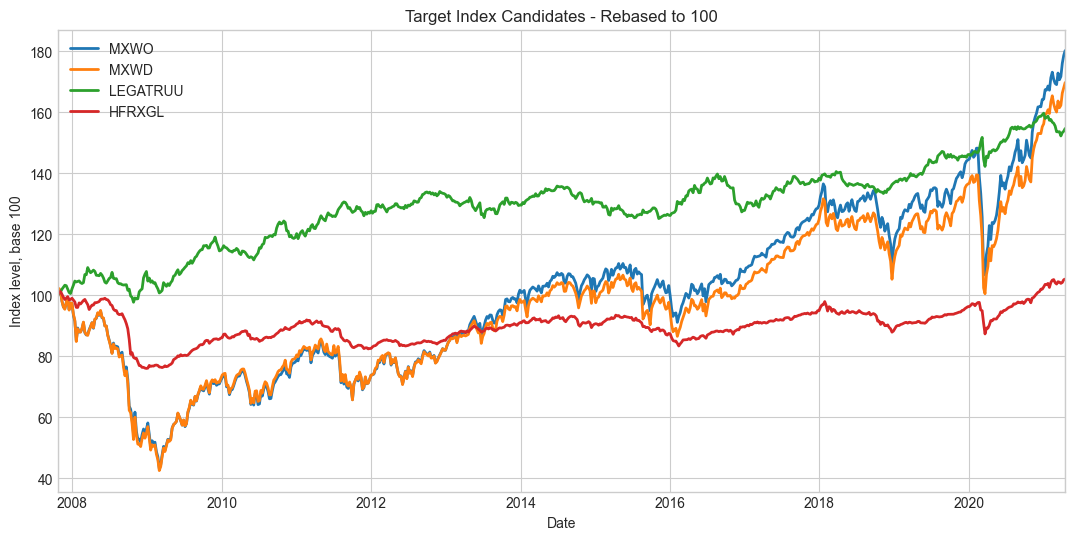

,Annualized Return,Annualized Volatility,Sharpe,Max Drawdown,Skewness,Kurtosis
MXWO,5.90%,17.52%,0.34,-57.61%,-0.68,4.36
MXWD,5.51%,17.78%,0.31,-58.39%,-0.64,4.66
LEGATRUU,3.37%,5.34%,0.63,-10.41%,-0.33,4.12
HFRXGL,0.50%,4.78%,0.10,-24.91%,-2.30,13.70


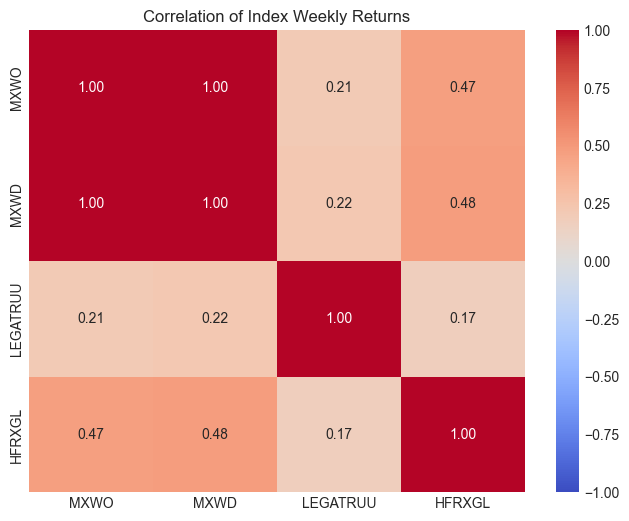

In [3]:
prices_base100 = data / data.iloc[0] * 100

ax = prices_base100[INDEX_COLUMNS].plot(figsize=(13, 6), linewidth=2)
ax.set_title("Target Index Candidates - Rebased to 100")
ax.set_ylabel("Index level, base 100")
ax.legend(loc="best")
plt.show()

returns_all = data.pct_change().dropna()
index_returns = returns_all[INDEX_COLUMNS]
futures_returns_all = returns_all[FUTURES_COLUMNS]

def max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    drawdown = cumulative / cumulative.cummax() - 1
    return drawdown.min()

index_stats = pd.DataFrame({
    "Annualized Return": index_returns.mean() * ANNUAL_FACTOR,
    "Annualized Volatility": index_returns.std() * np.sqrt(ANNUAL_FACTOR),
    "Sharpe": (index_returns.mean() * ANNUAL_FACTOR) / (index_returns.std() * np.sqrt(ANNUAL_FACTOR)),
    "Max Drawdown": index_returns.apply(max_drawdown),
    "Skewness": index_returns.skew(),
    "Kurtosis": index_returns.kurtosis(),
})

display(index_stats.style.format({
    "Annualized Return": "{:.2%}",
    "Annualized Volatility": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Max Drawdown": "{:.2%}",
    "Skewness": "{:.2f}",
    "Kurtosis": "{:.2f}",
}))

plt.figure(figsize=(8, 6))
sns.heatmap(index_returns.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation of Index Weekly Returns")
plt.show()

## 4. Construct the Target Portfolio

Following the template idea, I construct a target index as a weighted combination of existing index returns:

- 50% HFRXGL
- 25% MSCI World (`MXWO`)
- 25% Global Aggregate Bond (`LEGATRUU`)

This target is the black-box portfolio that the futures contracts try to replicate.

,Statistic,Value
0,Annualized return,0.0257
1,Annualized volatility,0.0633
2,Sharpe ratio,0.4056
3,Max drawdown,-0.2901
4,Skewness,-1.3451
5,Kurtosis,7.6442


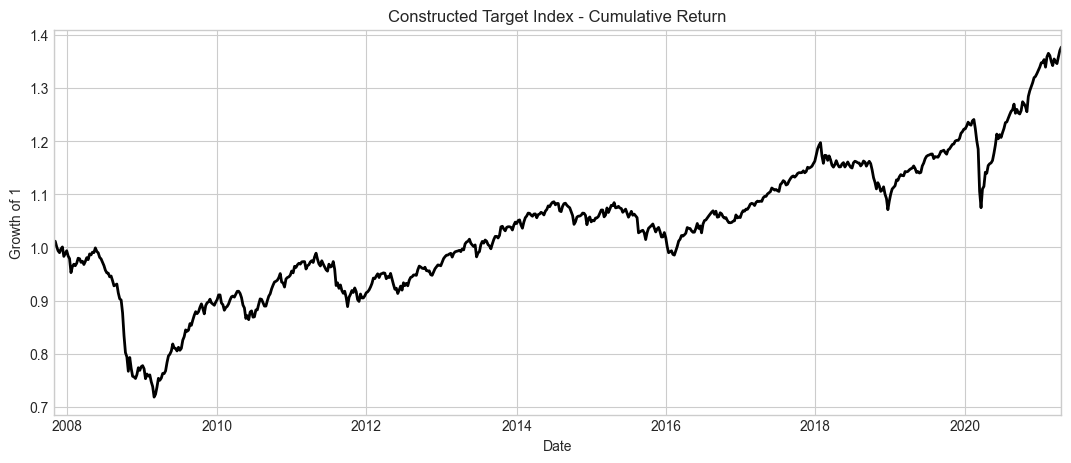

,Correlation with target
ES1,0.8379
NQ1,0.7469
VG1,0.7306
TP1,0.5988
LLL1,0.4987
CO1,0.4448
DU1,-0.2617
GC1,0.2183
TU2,-0.1528
RX1,-0.1307


In [4]:
TARGET_COMPONENTS = {
    "HFRXGL": 0.50,
    "MXWO": 0.25,
    "LEGATRUU": 0.25,
}

component_returns = returns_all[list(TARGET_COMPONENTS.keys())]
target_returns = sum(component_returns[name] * weight for name, weight in TARGET_COMPONENTS.items())
target_returns.name = "Target_Index"

futures_returns = returns_all[FUTURES_COLUMNS]
common_dates = target_returns.index.intersection(futures_returns.index)
y = target_returns.loc[common_dates]
X = futures_returns.loc[common_dates]

target_stats = pd.DataFrame({
    "Statistic": [
        "Annualized return",
        "Annualized volatility",
        "Sharpe ratio",
        "Max drawdown",
        "Skewness",
        "Kurtosis",
    ],
    "Value": [
        y.mean() * ANNUAL_FACTOR,
        y.std() * np.sqrt(ANNUAL_FACTOR),
        (y.mean() * ANNUAL_FACTOR) / (y.std() * np.sqrt(ANNUAL_FACTOR)),
        max_drawdown(y),
        y.skew(),
        y.kurtosis(),
    ],
})

display(target_stats)

target_cumulative = (1 + y).cumprod()
ax = target_cumulative.plot(figsize=(13, 5), linewidth=2, color="black")
ax.set_title("Constructed Target Index - Cumulative Return")
ax.set_ylabel("Growth of 1")
plt.show()

corr_to_target = X.corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)
display(corr_to_target.to_frame("Correlation with target"))

## 5. Modeling Helpers

The functions below keep the project consistent:

- Regression coefficients are interpreted as futures portfolio weights.
- The intercept is estimated but not traded, because an intercept is not a financial asset.
- Transaction cost is 5 bps times portfolio turnover.
- The weight vector is scaled down if gross exposure exceeds 200% or if estimated one-month 99% VaR exceeds 20%.
- Rolling models train only on past data and trade the next observation, avoiding look-ahead bias.

In [5]:
def annualized_return(r):
    return r.mean() * ANNUAL_FACTOR

def annualized_volatility(r):
    return r.std() * np.sqrt(ANNUAL_FACTOR)

def tracking_error(replica, target):
    diff = replica - target
    return diff.std() * np.sqrt(ANNUAL_FACTOR)

def information_ratio(replica, target):
    te = tracking_error(replica, target)
    if te == 0 or np.isnan(te):
        return np.nan
    return (replica - target).mean() * ANNUAL_FACTOR / te

def historical_var_1m(returns, confidence=VAR_CONFIDENCE, horizon=VAR_HORIZON_WEEKS):
    returns = pd.Series(returns).dropna()
    if len(returns) < 12:
        return 0.0
    sigma = returns.std()
    z = stats.norm.ppf(confidence)
    return float(-z * sigma * np.sqrt(horizon))

def scale_weights_for_risk(weights, hist_X):
    weights = pd.Series(weights, index=hist_X.columns).fillna(0.0).astype(float)
    gross = weights.abs().sum()
    if gross == 0:
        return weights, 1.0, 0.0, 0.0

    hist_portfolio = hist_X.dot(weights)
    var_est = historical_var_1m(hist_portfolio)

    gross_scale = min(1.0, MAX_GROSS_EXPOSURE / gross)
    var_scale = min(1.0, MONTHLY_VAR_LIMIT / var_est) if var_est > 0 else 1.0
    scale = min(gross_scale, var_scale)
    scaled = weights * scale

    return scaled, scale, scaled.abs().sum(), historical_var_1m(hist_X.dot(scaled))

def fit_linear_weights(X_train, y_train, model_type="ridge", alpha=1.0, l1_ratio=0.5, top_k=None):
    X_train = X_train.copy()
    y_train = y_train.copy()

    selected = X_train.columns.tolist()
    if top_k is not None and top_k < X_train.shape[1]:
        corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)
        selected = corr.head(top_k).index.tolist()
        X_train = X_train[selected]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    if model_type == "ols":
        model = LinearRegression()
    elif model_type == "ridge":
        model = Ridge(alpha=alpha)
    elif model_type == "lasso":
        model = Lasso(alpha=alpha, max_iter=20000)
    elif model_type == "elastic_net":
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=20000)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    model.fit(X_scaled, y_train.values)
    selected_weights = pd.Series(model.coef_ / scaler.scale_, index=selected)

    weights = pd.Series(0.0, index=FUTURES_COLUMNS)
    weights.loc[selected] = selected_weights

    intercept = float(model.intercept_ - np.sum(model.coef_ * scaler.mean_ / scaler.scale_))
    return weights, intercept, selected

def metrics_table(replica, target, weights=None, turnover=None, costs=None, label="model"):
    aligned = pd.concat([replica.rename("Replica"), target.rename("Target")], axis=1).dropna()
    replica = aligned["Replica"]
    target = aligned["Target"]
    diff = replica - target

    out = {
        "Model": label,
        "Obs": len(aligned),
        "Replica Return": annualized_return(replica),
        "Replica Vol": annualized_volatility(replica),
        "Replica Sharpe": annualized_return(replica) / annualized_volatility(replica),
        "Target Return": annualized_return(target),
        "Target Vol": annualized_volatility(target),
        "Tracking Error": tracking_error(replica, target),
        "Information Ratio": information_ratio(replica, target),
        "Correlation": replica.corr(target),
        "MAE": diff.abs().mean(),
        "Max Drawdown": max_drawdown(replica),
    }

    if weights is not None:
        out["Average Gross Exposure"] = weights.abs().sum(axis=1).mean()
        out["Average Net Exposure"] = weights.sum(axis=1).mean()
    if turnover is not None:
        out["Average Turnover"] = pd.Series(turnover).mean()
    if costs is not None:
        out["Total Transaction Cost"] = pd.Series(costs).sum()

    return out

def plot_replication(replica, target, title):
    aligned = pd.concat([replica.rename("Replica"), target.rename("Target")], axis=1).dropna()
    cumulative = (1 + aligned).cumprod()
    ax = cumulative.plot(figsize=(13, 6), linewidth=2)
    ax.set_title(title)
    ax.set_ylabel("Growth of 1")
    plt.show()

    diff = aligned["Replica"] - aligned["Target"]
    ax = diff.rolling(26).std().mul(np.sqrt(ANNUAL_FACTOR)).plot(figsize=(13, 4), color="purple")
    ax.set_title("Rolling 26-Week Tracking Error")
    ax.set_ylabel("Annualized tracking error")
    plt.show()

## 6. Static Linear Regression Models

Static models fit one set of weights using the first 70% of observations and test the fixed portfolio on the remaining 30%. This is a clean baseline before allowing weights to change over time.

In [6]:
split_idx = int(len(X) * 0.70)
X_train_static, X_test_static = X.iloc[:split_idx], X.iloc[split_idx:]
y_train_static, y_test_static = y.iloc[:split_idx], y.iloc[split_idx:]

static_specs = [
    {"model_type": "ols", "alpha": 0.0, "l1_ratio": 0.0, "top_k": None},
    {"model_type": "ridge", "alpha": 1.0, "l1_ratio": 0.0, "top_k": None},
    {"model_type": "lasso", "alpha": 0.001, "l1_ratio": 1.0, "top_k": None},
    {"model_type": "elastic_net", "alpha": 0.001, "l1_ratio": 0.5, "top_k": None},
    {"model_type": "ridge", "alpha": 1.0, "l1_ratio": 0.0, "top_k": 5},
]

static_results = []
static_weights = {}

for spec in static_specs:
    weights, intercept, selected = fit_linear_weights(X_train_static, y_train_static, **spec)
    weights, scale, gross, var_est = scale_weights_for_risk(weights, X_train_static)
    turnover = weights.abs().sum()
    cost = TRANSACTION_COST * turnover
    replica = X_test_static.dot(weights)
    if len(replica) > 0:
        replica.iloc[0] -= cost

    label = f"static_{spec['model_type']}_alpha{spec['alpha']}_top{spec['top_k']}"
    static_weights[label] = weights
    row = metrics_table(replica, y_test_static, label=label)
    row.update({
        "Gross Exposure": gross,
        "Estimated 1M VaR": var_est,
        "Selected Futures": ", ".join(selected),
    })
    static_results.append(row)

static_results_df = pd.DataFrame(static_results).sort_values("Tracking Error")
display(static_results_df)

static_weight_df = pd.DataFrame(static_weights).T
display(static_weight_df.style.format("{:.4f}"))

,Model,Obs,Replica Return,Replica Vol,Replica Sharpe,Target Return,Target Vol,Tracking Error,Information Ratio,Correlation,MAE,Max Drawdown,Gross Exposure,Estimated 1M VaR,Selected Futures
3,static_elastic_net_alpha0.001_topNone,212,0.0407,0.0461,0.8838,0.0600,0.0621,0.0328,-0.5884,0.8572,0.0028,-0.0907,0.4284,0.0333,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ..."
4,static_ridge_alpha1.0_top5,212,0.0325,0.0442,0.7360,0.0600,0.0621,0.0335,-0.8183,0.8535,0.0031,-0.0883,0.3410,0.0352,"ES1, VG1, NQ1, TP1, LLL1"
0,static_ols_alpha0.0_topNone,212,0.0480,0.0506,0.9494,0.0600,0.0621,0.0337,-0.3551,0.8400,0.0028,-0.0980,1.2426,0.0369,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ..."
1,static_ridge_alpha1.0_topNone,212,0.0481,0.0505,0.9517,0.0600,0.0621,0.0338,-0.3532,0.8394,0.0028,-0.0978,1.2414,0.0368,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ..."
2,static_lasso_alpha0.001_topNone,212,0.0350,0.0413,0.8482,0.0600,0.0621,0.0340,-0.7345,0.8595,0.0030,-0.0822,0.2912,0.0302,"RX1, TY1, GC1, CO1, ES1, VG1, NQ1, LLL1, TP1, ..."


,RX1,TY1,GC1,CO1,ES1,VG1,NQ1,LLL1,TP1,DU1,TU2
static_ols_alpha0.0_topNone,0.0599,0.1787,0.0369,0.0230,0.1651,0.0679,0.0151,0.0080,0.0471,-0.4913,0.1497
static_ridge_alpha1.0_topNone,0.0597,0.1780,0.0369,0.0230,0.1625,0.0680,0.0168,0.0083,0.0471,-0.4906,0.1505
static_lasso_alpha0.001_topNone,0.0000,0.0052,0.0237,0.0086,0.1761,0.0528,0.0000,0.0000,0.0248,-0.0000,0.0000
static_elastic_net_alpha0.001_topNone,0.0000,0.1003,0.0313,0.0155,0.1816,0.0599,0.0000,0.0029,0.0369,-0.0000,0.0000
static_ridge_alpha1.0_top5,0.0000,0.0000,0.0000,0.0000,0.1975,0.0639,-0.0143,0.0228,0.0424,0.0000,0.0000


## 7. Rolling Linear Models with Rebalancing

Static weights are rarely enough for hedge-fund-like replication. The next block runs rolling regressions with:

- Training windows of 52, 104, and 156 weeks.
- Rebalancing every 4 or 12 weeks.
- OLS, Ridge, Lasso, Elastic Net.
- Some model variants using only the top 5 futures by in-window correlation.

In [7]:
def backtest_rolling_linear(model_type, window, rebalance_every, alpha=1.0, l1_ratio=0.5, top_k=None):
    dates = []
    replica_returns = []
    target_out = []
    weights_out = []
    turnover_out = []
    costs_out = []
    selected_out = []

    current_weights = pd.Series(0.0, index=FUTURES_COLUMNS)

    for t in range(window, len(X)):
        date = X.index[t]
        should_rebalance = ((t - window) % rebalance_every == 0)

        if should_rebalance:
            X_train = X.iloc[t - window:t]
            y_train = y.iloc[t - window:t]
            raw_weights, intercept, selected = fit_linear_weights(
                X_train, y_train, model_type=model_type, alpha=alpha,
                l1_ratio=l1_ratio, top_k=top_k
            )
            new_weights, scale, gross, var_est = scale_weights_for_risk(raw_weights, X_train)
            turnover = float((new_weights - current_weights).abs().sum())
            current_weights = new_weights
            cost = TRANSACTION_COST * turnover
        else:
            selected = []
            turnover = 0.0
            cost = 0.0

        weekly_replica = float(X.iloc[t].dot(current_weights) - cost)

        dates.append(date)
        replica_returns.append(weekly_replica)
        target_out.append(float(y.iloc[t]))
        weights_out.append(current_weights.copy())
        turnover_out.append(turnover)
        costs_out.append(cost)
        selected_out.append(selected)

    replica = pd.Series(replica_returns, index=dates, name="Replica")
    target = pd.Series(target_out, index=dates, name="Target")
    weights_df = pd.DataFrame(weights_out, index=dates)
    turnover_series = pd.Series(turnover_out, index=dates, name="Turnover")
    cost_series = pd.Series(costs_out, index=dates, name="Transaction_Cost")

    label = f"{model_type}_w{window}_reb{rebalance_every}_a{alpha}_l1{l1_ratio}_top{top_k}"
    result = metrics_table(
        replica, target, weights=weights_df,
        turnover=turnover_series, costs=cost_series, label=label
    )
    result.update({
        "Model Type": model_type,
        "Window": window,
        "Rebalance Every": rebalance_every,
        "Alpha": alpha,
        "L1 Ratio": l1_ratio,
        "Top K": top_k,
    })

    details = {
        "replica": replica,
        "target": target,
        "weights": weights_df,
        "turnover": turnover_series,
        "costs": cost_series,
    }

    return result, details

grid = []
for window in [52, 104, 156]:
    for rebalance in [4, 12]:
        grid.append({"model_type": "ols", "window": window, "rebalance_every": rebalance, "alpha": 0.0, "l1_ratio": 0.0, "top_k": None})
        for alpha in [0.1, 1.0, 10.0]:
            grid.append({"model_type": "ridge", "window": window, "rebalance_every": rebalance, "alpha": alpha, "l1_ratio": 0.0, "top_k": None})
        for alpha in [0.001, 0.01]:
            grid.append({"model_type": "lasso", "window": window, "rebalance_every": rebalance, "alpha": alpha, "l1_ratio": 1.0, "top_k": None})
        for alpha in [0.001, 0.01]:
            for l1_ratio in [0.3, 0.7]:
                grid.append({"model_type": "elastic_net", "window": window, "rebalance_every": rebalance, "alpha": alpha, "l1_ratio": l1_ratio, "top_k": None})
        grid.append({"model_type": "ridge", "window": window, "rebalance_every": rebalance, "alpha": 1.0, "l1_ratio": 0.0, "top_k": 5})
        grid.append({"model_type": "elastic_net", "window": window, "rebalance_every": rebalance, "alpha": 0.001, "l1_ratio": 0.5, "top_k": 5})

rolling_results = []
rolling_details = {}

for spec in grid:
    result, details = backtest_rolling_linear(**spec)
    rolling_results.append(result)
    rolling_details[result["Model"]] = details

rolling_results_df = pd.DataFrame(rolling_results)
sort_cols = ["Tracking Error", "Correlation", "Average Gross Exposure"]
leaderboard = rolling_results_df.sort_values(["Tracking Error", "Correlation"], ascending=[True, False])
display(leaderboard.head(15))

,Model,Obs,Replica Return,Replica Vol,Replica Sharpe,Target Return,Target Vol,Tracking Error,Information Ratio,Correlation,...,Average Gross Exposure,Average Net Exposure,Average Turnover,Total Transaction Cost,Model Type,Window,Rebalance Every,Alpha,L1 Ratio,Top K
54,elastic_net_w156_reb4_a0.001_l10.3_topNone,548,0.0389,0.0460,0.8443,0.0382,0.0554,0.0281,0.0247,0.8623,...,0.5738,0.4722,0.0209,0.0057,elastic_net,156,4,0.0010,0.3000,NaN
66,elastic_net_w156_reb12_a0.001_l10.3_topNone,548,0.0407,0.0461,0.8818,0.0382,0.0554,0.0283,0.0885,0.8600,...,0.5751,0.4694,0.0142,0.0039,elastic_net,156,12,0.0010,0.3000,NaN
42,elastic_net_w104_reb12_a0.001_l10.3_topNone,600,0.0364,0.0447,0.8155,0.0391,0.0561,0.0284,-0.0929,0.8658,...,0.6619,0.5362,0.0203,0.0061,elastic_net,104,12,0.0010,0.3000,NaN
30,elastic_net_w104_reb4_a0.001_l10.3_topNone,600,0.0368,0.0458,0.8038,0.0391,0.0561,0.0284,-0.0800,0.8635,...,0.6829,0.5573,0.0324,0.0097,elastic_net,104,4,0.0010,0.3000,NaN
55,elastic_net_w156_reb4_a0.001_l10.7_topNone,548,0.0362,0.0420,0.8612,0.0382,0.0554,0.0287,-0.0706,0.8616,...,0.3462,0.3462,0.0095,0.0026,elastic_net,156,4,0.0010,0.7000,NaN
67,elastic_net_w156_reb12_a0.001_l10.7_topNone,548,0.0375,0.0420,0.8923,0.0382,0.0554,0.0288,-0.0233,0.8604,...,0.3453,0.3453,0.0064,0.0018,elastic_net,156,12,0.0010,0.7000,NaN
48,ols_w156_reb4_a0.0_l10.0_topNone,548,0.0336,0.0480,0.6991,0.0382,0.0554,0.0289,-0.1587,0.8530,...,1.5728,0.0095,0.0492,0.0135,ols,156,4,0.0000,0.0000,NaN
49,ridge_w156_reb4_a0.1_l10.0_topNone,548,0.0336,0.0480,0.7002,0.0382,0.0554,0.0289,-0.1573,0.8529,...,1.5708,0.0108,0.0491,0.0134,ridge,156,4,0.1000,0.0000,NaN
60,ols_w156_reb12_a0.0_l10.0_topNone,548,0.0376,0.0488,0.7699,0.0382,0.0554,0.0290,-0.0213,0.8529,...,1.5842,0.0109,0.0333,0.0091,ols,156,12,0.0000,0.0000,NaN
61,ridge_w156_reb12_a0.1_l10.0_topNone,548,0.0376,0.0488,0.7709,0.0382,0.0554,0.0290,-0.0201,0.8529,...,1.5821,0.0123,0.0332,0.0091,ridge,156,12,0.1000,0.0000,NaN


## 8. Best Rolling Linear Model

The best rolling model is selected primarily by low tracking error. Correlation and exposure are also reviewed, because a low-error model with unstable or excessive exposure would be less convincing as a tradable clone.

Best rolling linear model:
elastic_net_w156_reb4_a0.001_l10.3_topNone


,54
Model,elastic_net_w156_reb4_a0.001_l10.3_topNone
Obs,548
Replica Return,0.0389
Replica Vol,0.0460
Replica Sharpe,0.8443
Target Return,0.0382
Target Vol,0.0554
Tracking Error,0.0281
Information Ratio,0.0247
Correlation,0.8623


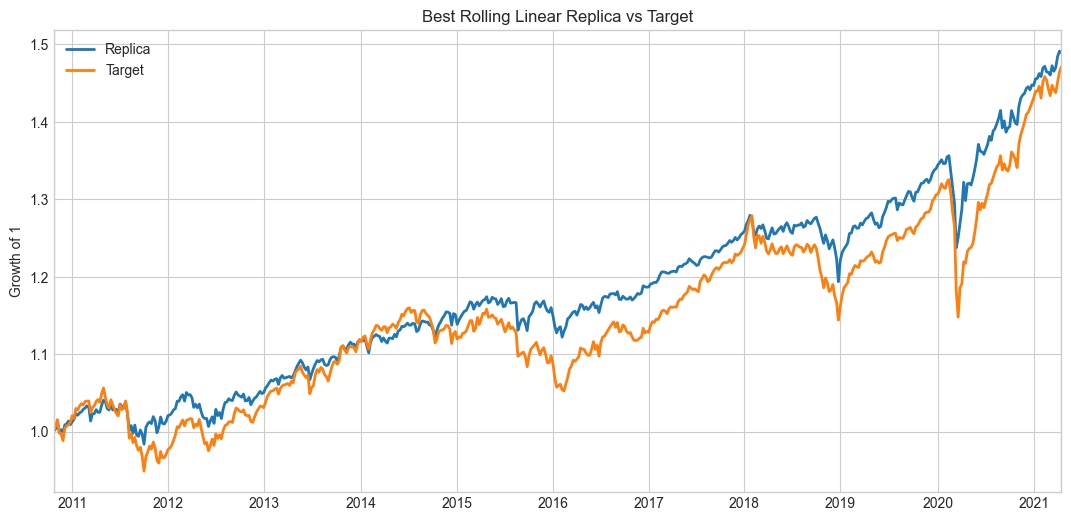

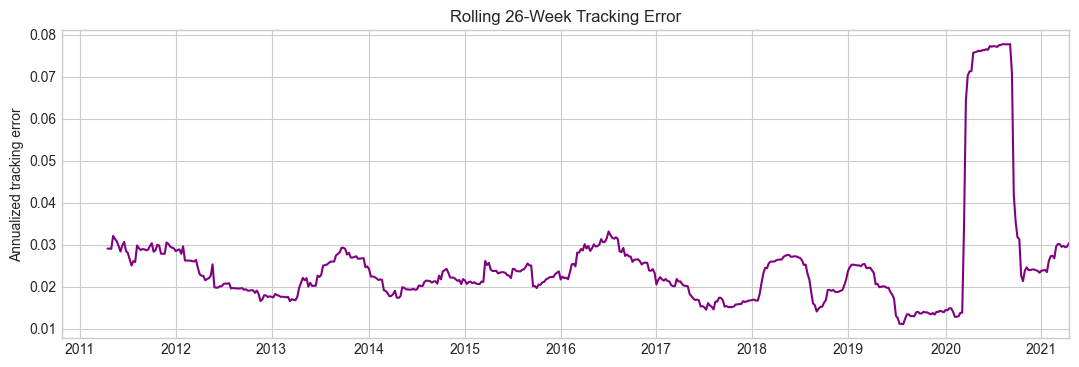

,Average Absolute Weight
ES1,0.1925
DU1,0.1307
TY1,0.0607
VG1,0.0475
GC1,0.0397
TP1,0.0316
TU2,0.0221
NQ1,0.0181
RX1,0.0132
CO1,0.0123


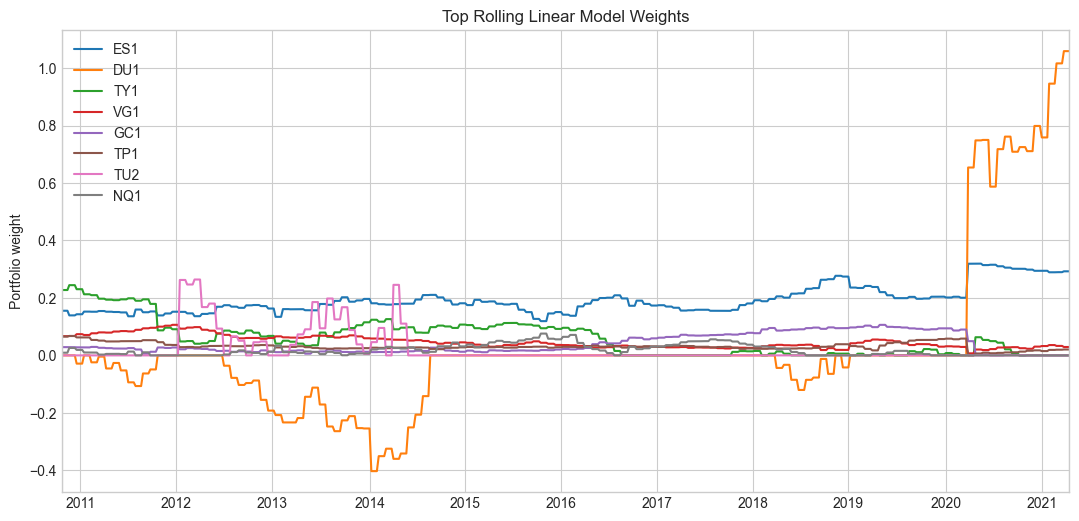

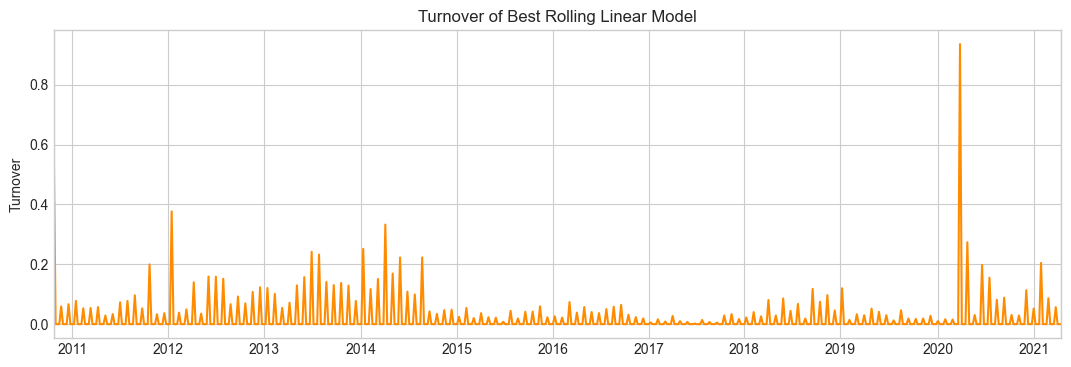

In [8]:
best_linear_label = leaderboard.iloc[0]["Model"]
best_linear = rolling_details[best_linear_label]

print("Best rolling linear model:")
print(best_linear_label)
display(leaderboard.head(1).T)

plot_replication(best_linear["replica"], best_linear["target"], "Best Rolling Linear Replica vs Target")

avg_abs_weights = best_linear["weights"].abs().mean().sort_values(ascending=False)
display(avg_abs_weights.to_frame("Average Absolute Weight"))

top_weight_cols = avg_abs_weights.head(8).index.tolist()
ax = best_linear["weights"][top_weight_cols].plot(figsize=(13, 6), linewidth=1.5)
ax.set_title("Top Rolling Linear Model Weights")
ax.set_ylabel("Portfolio weight")
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
best_linear["turnover"].plot(ax=ax, color="darkorange")
ax.set_title("Turnover of Best Rolling Linear Model")
ax.set_ylabel("Turnover")
plt.show()

## 9. Kalman Filter Dynamic Replication

The Kalman filter treats portfolio weights as hidden states that evolve through time:

- State equation: current weights equal previous weights plus small Gaussian shocks.
- Observation equation: target return equals futures returns times the hidden weights plus noise.

To avoid look-ahead bias, the portfolio return at time `t` uses the predicted weights before observing the target return at `t`. After the target return is observed, the filter updates weights for future periods.

In [9]:
def initialize_ridge_weights(X_init, y_init, alpha=1.0):
    weights, intercept, selected = fit_linear_weights(X_init, y_init, model_type="ridge", alpha=alpha)
    weights, scale, gross, var_est = scale_weights_for_risk(weights, X_init)
    return weights

def backtest_kalman(initial_window=104, process_noise=0.01, obs_noise_scale=1.0):
    X_values = X.values
    y_values = y.values
    dates = X.index
    n_assets = X.shape[1]

    initial_weights = initialize_ridge_weights(X.iloc[:initial_window], y.iloc[:initial_window], alpha=1.0)
    w = initial_weights.values.reshape(-1, 1)
    P = np.eye(n_assets) * 0.25

    Q = np.eye(n_assets) * (process_noise ** 2)
    base_obs_std = y.iloc[:initial_window].std()
    R = float((obs_noise_scale * base_obs_std) ** 2)
    R = max(R, 1e-10)

    replica_returns = []
    target_out = []
    weights_out = []
    turnover_out = []
    costs_out = []
    out_dates = []

    prev_trade_weights = pd.Series(0.0, index=FUTURES_COLUMNS)

    for t in range(initial_window, len(X)):
        x_t = X_values[t].reshape(1, -1)

        # Prediction step.
        w_pred = w
        P_pred = P + Q

        raw_trade_weights = pd.Series(w_pred.flatten(), index=FUTURES_COLUMNS)
        hist_X = X.iloc[max(0, t - initial_window):t]
        trade_weights, scale, gross, var_est = scale_weights_for_risk(raw_trade_weights, hist_X)

        turnover = float((trade_weights - prev_trade_weights).abs().sum())
        cost = TRANSACTION_COST * turnover
        replica_return = float(X.iloc[t].dot(trade_weights) - cost)

        # Observation update after observing y_t.
        y_pred = float(x_t @ w_pred)
        innovation = float(y_values[t] - y_pred)
        S = float(x_t @ P_pred @ x_t.T + R)
        K = (P_pred @ x_t.T) / S
        w = w_pred + K * innovation
        P = (np.eye(n_assets) - K @ x_t) @ P_pred

        out_dates.append(dates[t])
        replica_returns.append(replica_return)
        target_out.append(float(y_values[t]))
        weights_out.append(trade_weights.copy())
        turnover_out.append(turnover)
        costs_out.append(cost)

        prev_trade_weights = trade_weights

    replica = pd.Series(replica_returns, index=out_dates, name="Replica")
    target = pd.Series(target_out, index=out_dates, name="Target")
    weights_df = pd.DataFrame(weights_out, index=out_dates)
    turnover_series = pd.Series(turnover_out, index=out_dates, name="Turnover")
    cost_series = pd.Series(costs_out, index=out_dates, name="Transaction_Cost")

    label = f"kalman_init{initial_window}_q{process_noise}_rscale{obs_noise_scale}"
    result = metrics_table(
        replica, target, weights=weights_df,
        turnover=turnover_series, costs=cost_series, label=label
    )
    result.update({
        "Model Type": "kalman",
        "Initial Window": initial_window,
        "Process Noise": process_noise,
        "Observation Noise Scale": obs_noise_scale,
    })
    details = {
        "replica": replica,
        "target": target,
        "weights": weights_df,
        "turnover": turnover_series,
        "costs": cost_series,
    }
    return result, details

kalman_results = []
kalman_details = {}

for initial_window in [52, 104, 156]:
    for process_noise in [0.0025, 0.005, 0.01, 0.02]:
        for obs_noise_scale in [0.5, 1.0, 2.0]:
            result, details = backtest_kalman(
                initial_window=initial_window,
                process_noise=process_noise,
                obs_noise_scale=obs_noise_scale,
            )
            kalman_results.append(result)
            kalman_details[result["Model"]] = details

kalman_results_df = pd.DataFrame(kalman_results)
kalman_leaderboard = kalman_results_df.sort_values(["Tracking Error", "Correlation"], ascending=[True, False])
display(kalman_leaderboard.head(10))

,Model,Obs,Replica Return,Replica Vol,Replica Sharpe,Target Return,Target Vol,Tracking Error,Information Ratio,Correlation,MAE,Max Drawdown,Average Gross Exposure,Average Net Exposure,Average Turnover,Total Transaction Cost,Model Type,Initial Window,Process Noise,Observation Noise Scale
26,kalman_init156_q0.0025_rscale2.0,548,0.0366,0.0490,0.7462,0.0382,0.0554,0.0276,-0.0579,0.8675,0.0026,-0.0938,1.0757,0.1625,0.0130,0.0036,kalman,156,0.0025,2.0000
14,kalman_init104_q0.0025_rscale2.0,600,0.0373,0.0493,0.7573,0.0391,0.0561,0.0276,-0.0639,0.8704,0.0027,-0.0933,1.0419,0.2293,0.0121,0.0036,kalman,104,0.0025,2.0000
17,kalman_init104_q0.005_rscale2.0,600,0.0376,0.0492,0.7640,0.0391,0.0561,0.0279,-0.0531,0.8681,0.0027,-0.0919,1.0426,0.2315,0.0126,0.0038,kalman,104,0.0050,2.0000
29,kalman_init156_q0.005_rscale2.0,548,0.0370,0.0490,0.7553,0.0382,0.0554,0.0279,-0.0426,0.8643,0.0026,-0.0923,1.0741,0.1634,0.0137,0.0037,kalman,156,0.0050,2.0000
25,kalman_init156_q0.0025_rscale1.0,548,0.0361,0.0489,0.7376,0.0382,0.0554,0.0280,-0.0755,0.8630,0.0027,-0.0926,1.1188,0.1111,0.0202,0.0055,kalman,156,0.0025,1.0000
13,kalman_init104_q0.0025_rscale1.0,600,0.0367,0.0490,0.7486,0.0391,0.0561,0.0281,-0.0841,0.8661,0.0027,-0.0919,1.0637,0.1973,0.0191,0.0057,kalman,104,0.0025,1.0000
20,kalman_init104_q0.01_rscale2.0,600,0.0385,0.0496,0.7765,0.0391,0.0561,0.0283,-0.0194,0.8635,0.0027,-0.0907,1.0487,0.2380,0.0145,0.0043,kalman,104,0.0100,2.0000
32,kalman_init156_q0.01_rscale2.0,548,0.0382,0.0493,0.7755,0.0382,0.0554,0.0285,0.0017,0.8585,0.0026,-0.0907,1.0745,0.1658,0.0157,0.0043,kalman,156,0.0100,2.0000
16,kalman_init104_q0.005_rscale1.0,600,0.0377,0.0495,0.7615,0.0391,0.0561,0.0285,-0.0486,0.8614,0.0027,-0.0907,1.0676,0.2091,0.0207,0.0062,kalman,104,0.0050,1.0000
28,kalman_init156_q0.005_rscale1.0,548,0.0374,0.0492,0.7584,0.0382,0.0554,0.0286,-0.0290,0.8571,0.0027,-0.0908,1.1139,0.1182,0.0220,0.0060,kalman,156,0.0050,1.0000


## 10. Best Kalman Filter Model

The Kalman model adapts weights every week. That flexibility can improve tracking, but it may also increase turnover and transaction costs. The table and plots below show whether the dynamic behavior is worth it.

Best Kalman model:
kalman_init156_q0.0025_rscale2.0


,26
Model,kalman_init156_q0.0025_rscale2.0
Obs,548
Replica Return,0.0366
Replica Vol,0.0490
Replica Sharpe,0.7462
Target Return,0.0382
Target Vol,0.0554
Tracking Error,0.0276
Information Ratio,-0.0579
Correlation,0.8675


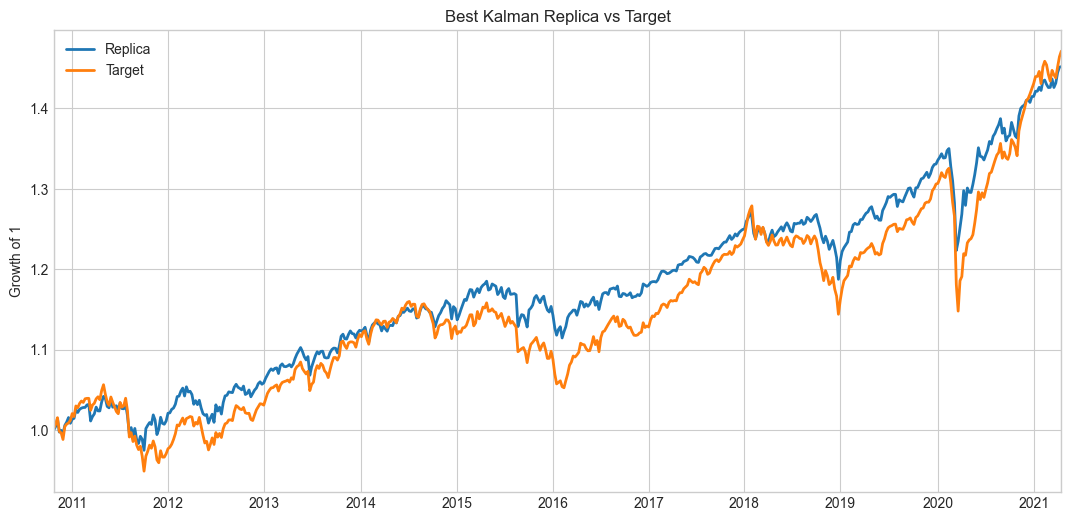

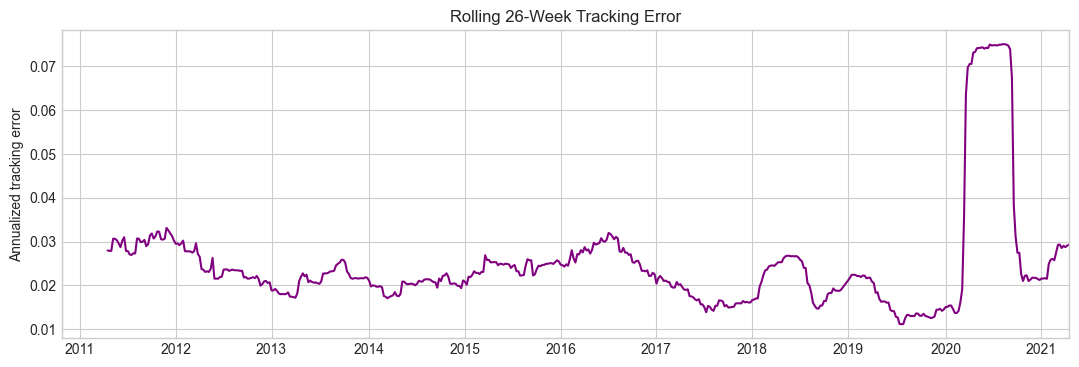

,Average Absolute Weight
DU1,0.4104
ES1,0.1885
TY1,0.1539
VG1,0.0745
RX1,0.0604
LLL1,0.0436
TU2,0.0404
TP1,0.0329
GC1,0.0321
CO1,0.0208


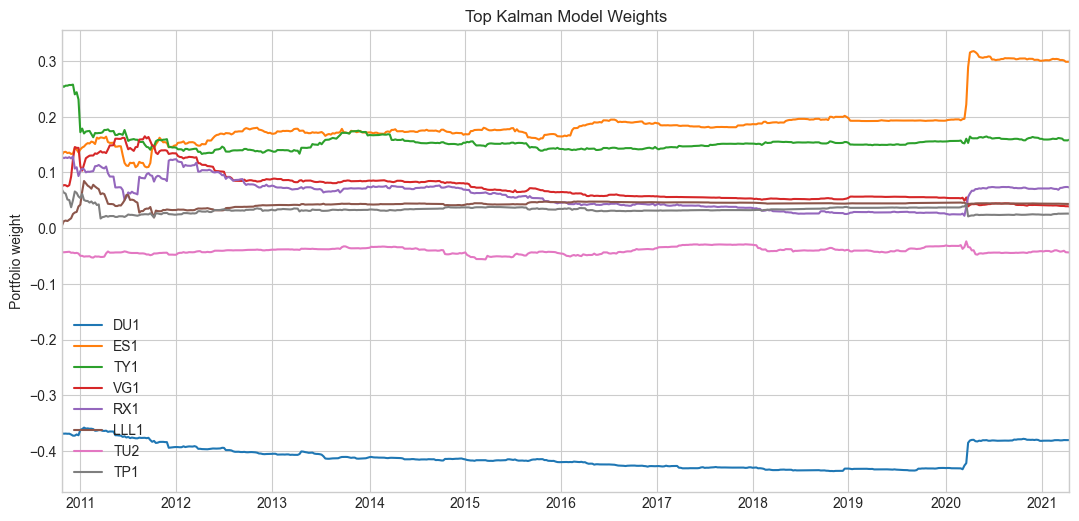

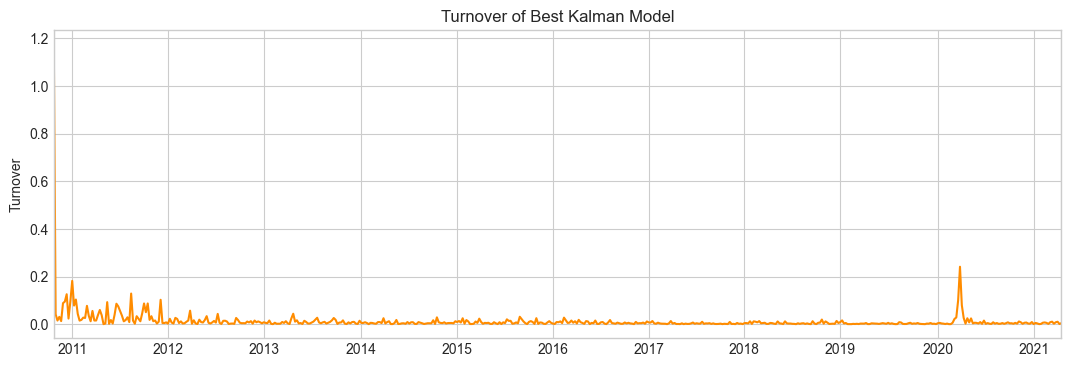

In [10]:
best_kalman_label = kalman_leaderboard.iloc[0]["Model"]
best_kalman = kalman_details[best_kalman_label]

print("Best Kalman model:")
print(best_kalman_label)
display(kalman_leaderboard.head(1).T)

plot_replication(best_kalman["replica"], best_kalman["target"], "Best Kalman Replica vs Target")

avg_abs_kalman_weights = best_kalman["weights"].abs().mean().sort_values(ascending=False)
display(avg_abs_kalman_weights.to_frame("Average Absolute Weight"))

top_kalman_cols = avg_abs_kalman_weights.head(8).index.tolist()
ax = best_kalman["weights"][top_kalman_cols].plot(figsize=(13, 6), linewidth=1.5)
ax.set_title("Top Kalman Model Weights")
ax.set_ylabel("Portfolio weight")
plt.show()

fig, ax = plt.subplots(figsize=(13, 4))
best_kalman["turnover"].plot(ax=ax, color="darkorange")
ax.set_title("Turnover of Best Kalman Model")
ax.set_ylabel("Turnover")
plt.show()

## 11. Final Model Comparison and Interpretation

This final section compares the best static, best rolling linear, and best Kalman filter approaches. In a real investment setting, the preferred model is not necessarily the one with the lowest tracking error; it should also have reasonable turnover, stable exposures, and understandable weights.

,Model,Obs,Replica Return,Replica Vol,Replica Sharpe,Target Return,Target Vol,Tracking Error,Information Ratio,Correlation,MAE,Max Drawdown,Average Gross Exposure,Average Net Exposure,Average Turnover,Total Transaction Cost
2,Best Kalman Filter,548,0.0366,0.0490,0.7462,0.0382,0.0554,0.0276,-0.0579,0.8675,0.0026,-0.0938,1.0757,0.1625,0.0130,0.0036
1,Best Rolling Linear,548,0.0389,0.0460,0.8443,0.0382,0.0554,0.0281,0.0247,0.8623,0.0027,-0.0876,0.5738,0.4722,0.0209,0.0057
0,Best Static Linear,212,0.0408,0.0461,0.8849,0.0600,0.0621,0.0328,-0.5868,0.8572,0.0028,-0.0907,NaN,NaN,NaN,NaN


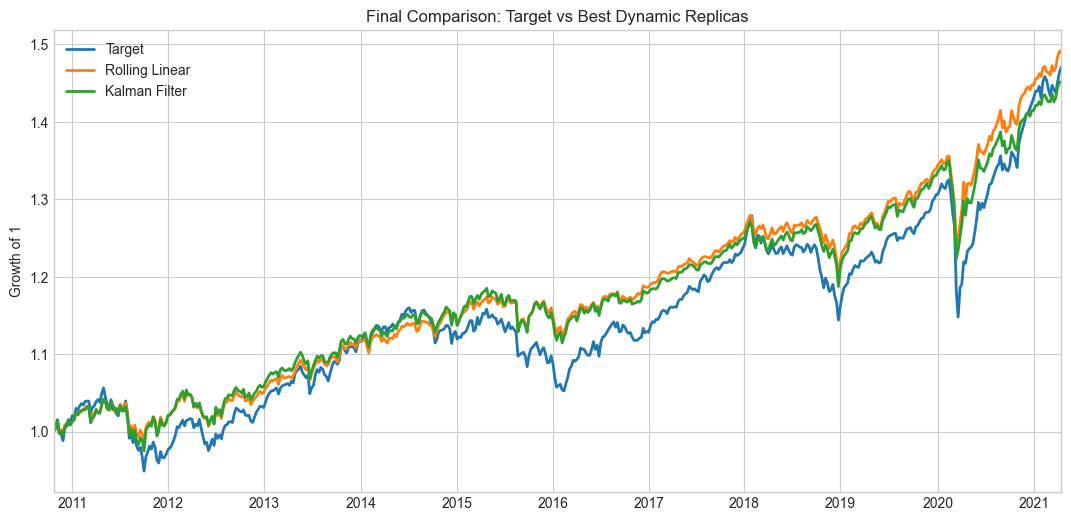

Suggested interpretation:
- OLS is useful as a transparent baseline but can be unstable when futures are correlated.
- Ridge often gives the most robust linear clone because it shrinks weights without forcing too many zeros.
- Lasso and Elastic Net are useful when you want sparse futures selection, but alpha must be tuned carefully.
- The Kalman filter is attractive when exposures are genuinely time-varying, but turnover and cost matter.
- For a practical project answer, prefer the model with low tracking error, high correlation, controlled exposure, and acceptable turnover.


In [11]:
best_static_label = static_results_df.iloc[0]["Model"]
best_static_weights = static_weights[best_static_label]
best_static_replica = X_test_static.dot(best_static_weights)

comparison_rows = []
comparison_rows.append(metrics_table(best_static_replica, y_test_static, label="Best Static Linear"))
comparison_rows.append(metrics_table(
    best_linear["replica"], best_linear["target"],
    weights=best_linear["weights"], turnover=best_linear["turnover"],
    costs=best_linear["costs"], label="Best Rolling Linear"
))
comparison_rows.append(metrics_table(
    best_kalman["replica"], best_kalman["target"],
    weights=best_kalman["weights"], turnover=best_kalman["turnover"],
    costs=best_kalman["costs"], label="Best Kalman Filter"
))

final_comparison = pd.DataFrame(comparison_rows)
display(final_comparison.sort_values("Tracking Error"))

aligned_plot = pd.concat([
    best_linear["target"].rename("Target"),
    best_linear["replica"].rename("Rolling Linear"),
    best_kalman["replica"].rename("Kalman Filter"),
], axis=1).dropna()

cumulative = (1 + aligned_plot).cumprod()
ax = cumulative.plot(figsize=(13, 6), linewidth=2)
ax.set_title("Final Comparison: Target vs Best Dynamic Replicas")
ax.set_ylabel("Growth of 1")
plt.show()

print("Suggested interpretation:")
print("- OLS is useful as a transparent baseline but can be unstable when futures are correlated.")
print("- Ridge often gives the most robust linear clone because it shrinks weights without forcing too many zeros.")
print("- Lasso and Elastic Net are useful when you want sparse futures selection, but alpha must be tuned carefully.")
print("- The Kalman filter is attractive when exposures are genuinely time-varying, but turnover and cost matter.")
print("- For a practical project answer, prefer the model with low tracking error, high correlation, controlled exposure, and acceptable turnover.")

## 12. Additional Project Enhancements

This section adds the main improvements suggested after the first project version:

- A second experiment that replicates `HFRXGL` directly.
- Market-regime analysis.
- Residual and tracking-error diagnostics.
- Gross versus net performance after transaction costs.
- Turnover thresholding to avoid unnecessary small trades.
- A constrained long-only regression benchmark.
- Kalman filter parameter sensitivity.

### 12.1 Generic Rolling Backtest for Alternative Targets

The first notebook version focused on the constructed target index. The function below allows the same rolling linear framework to be reused for any target series, including `HFRXGL` alone.

In [12]:
def backtest_rolling_linear_custom(
    target_series,
    futures_X,
    model_type,
    window,
    rebalance_every,
    alpha=1.0,
    l1_ratio=0.5,
    top_k=None,
    turnover_threshold=0.0,
    charge_costs=True,
):
    target_series = target_series.loc[futures_X.index].dropna()
    futures_X = futures_X.loc[target_series.index]

    dates = []
    replica_returns = []
    target_out = []
    weights_out = []
    turnover_out = []
    costs_out = []

    current_weights = pd.Series(0.0, index=futures_X.columns)

    for t in range(window, len(futures_X)):
        should_rebalance = ((t - window) % rebalance_every == 0)

        if should_rebalance:
            X_train = futures_X.iloc[t - window:t]
            y_train = target_series.iloc[t - window:t]
            raw_weights, intercept, selected = fit_linear_weights(
                X_train,
                y_train,
                model_type=model_type,
                alpha=alpha,
                l1_ratio=l1_ratio,
                top_k=top_k,
            )
            new_weights, scale, gross, var_est = scale_weights_for_risk(raw_weights, X_train)
            proposed_turnover = float((new_weights - current_weights).abs().sum())

            if proposed_turnover >= turnover_threshold:
                current_weights = new_weights
                turnover = proposed_turnover
            else:
                turnover = 0.0

            cost = TRANSACTION_COST * turnover if charge_costs else 0.0
        else:
            turnover = 0.0
            cost = 0.0

        weekly_replica = float(futures_X.iloc[t].dot(current_weights) - cost)

        dates.append(futures_X.index[t])
        replica_returns.append(weekly_replica)
        target_out.append(float(target_series.iloc[t]))
        weights_out.append(current_weights.copy())
        turnover_out.append(turnover)
        costs_out.append(cost)

    replica = pd.Series(replica_returns, index=dates, name="Replica")
    target = pd.Series(target_out, index=dates, name="Target")
    weights_df = pd.DataFrame(weights_out, index=dates)
    turnover_series = pd.Series(turnover_out, index=dates, name="Turnover")
    cost_series = pd.Series(costs_out, index=dates, name="Transaction_Cost")

    label = f"{model_type}_w{window}_reb{rebalance_every}_a{alpha}_l1{l1_ratio}_top{top_k}_thr{turnover_threshold}"
    result = metrics_table(
        replica,
        target,
        weights=weights_df,
        turnover=turnover_series,
        costs=cost_series,
        label=label,
    )
    result.update({
        "Model Type": model_type,
        "Window": window,
        "Rebalance Every": rebalance_every,
        "Alpha": alpha,
        "L1 Ratio": l1_ratio,
        "Top K": top_k,
        "Turnover Threshold": turnover_threshold,
    })

    details = {
        "replica": replica,
        "target": target,
        "weights": weights_df,
        "turnover": turnover_series,
        "costs": cost_series,
    }
    return result, details

### 12.2 HFRXGL-Only Replication

The constructed target is useful for a controlled experiment, but the business case is mainly about hedge-fund replication. Therefore, this section replicates `HFRXGL` directly using the futures universe.

,Model,Obs,Replica Return,Replica Vol,Replica Sharpe,Target Return,Target Vol,Tracking Error,Information Ratio,Correlation,...,Average Turnover,Total Transaction Cost,Model Type,Window,Rebalance Every,Alpha,L1 Ratio,Top K,Turnover Threshold,Target Name
47,elastic_net_w104_reb12_a0.001_l10.5_top5_thr0.0,600,0.0120,0.0199,0.6059,0.0192,0.0426,0.0375,-0.1922,0.4722,...,0.0111,0.0033,elastic_net,104,12,0.0010,0.5000,5.0000,0.0000,HFRXGL
71,elastic_net_w156_reb12_a0.001_l10.5_top5_thr0.0,548,0.0164,0.0199,0.8256,0.0172,0.0429,0.0376,-0.0209,0.4821,...,0.0079,0.0022,elastic_net,156,12,0.0010,0.5000,5.0000,0.0000,HFRXGL
59,elastic_net_w156_reb4_a0.001_l10.5_top5_thr0.0,548,0.0155,0.0196,0.7932,0.0172,0.0429,0.0377,-0.0442,0.4758,...,0.0115,0.0031,elastic_net,156,4,0.0010,0.5000,5.0000,0.0000,HFRXGL
35,elastic_net_w104_reb4_a0.001_l10.5_top5_thr0.0,600,0.0125,0.0208,0.6020,0.0192,0.0426,0.0378,-0.1772,0.4620,...,0.0182,0.0055,elastic_net,104,4,0.0010,0.5000,5.0000,0.0000,HFRXGL
42,elastic_net_w104_reb12_a0.001_l10.3_topNone_th...,600,0.0119,0.0216,0.5502,0.0192,0.0426,0.0378,-0.1950,0.4633,...,0.0265,0.0079,elastic_net,104,12,0.0010,0.3000,NaN,0.0000,HFRXGL
46,ridge_w104_reb12_a1.0_l10.0_top5_thr0.0,600,0.0138,0.0254,0.5431,0.0192,0.0426,0.0378,-0.1448,0.4752,...,0.0221,0.0066,ridge,104,12,1.0000,0.0000,5.0000,0.0000,HFRXGL
30,elastic_net_w104_reb4_a0.001_l10.3_topNone_thr0.0,600,0.0112,0.0221,0.5070,0.0192,0.0426,0.0378,-0.2131,0.4626,...,0.0402,0.0121,elastic_net,104,4,0.0010,0.3000,NaN,0.0000,HFRXGL
67,elastic_net_w156_reb12_a0.001_l10.7_topNone_th...,548,0.0156,0.0182,0.8563,0.0172,0.0429,0.0378,-0.0423,0.4740,...,0.0081,0.0022,elastic_net,156,12,0.0010,0.7000,NaN,0.0000,HFRXGL
43,elastic_net_w104_reb12_a0.001_l10.7_topNone_th...,600,0.0111,0.0178,0.6258,0.0192,0.0426,0.0378,-0.2142,0.4605,...,0.0143,0.0043,elastic_net,104,12,0.0010,0.7000,NaN,0.0000,HFRXGL
66,elastic_net_w156_reb12_a0.001_l10.3_topNone_th...,548,0.0189,0.0224,0.8430,0.0172,0.0429,0.0379,0.0451,0.4723,...,0.0179,0.0049,elastic_net,156,12,0.0010,0.3000,NaN,0.0000,HFRXGL


Best HFRXGL-only rolling model:
elastic_net_w104_reb12_a0.001_l10.5_top5_thr0.0


,47
Model,elastic_net_w104_reb12_a0.001_l10.5_top5_thr0.0
Obs,600
Replica Return,0.0120
Replica Vol,0.0199
Replica Sharpe,0.6059
Target Return,0.0192
Target Vol,0.0426
Tracking Error,0.0375
Information Ratio,-0.1922
Correlation,0.4722


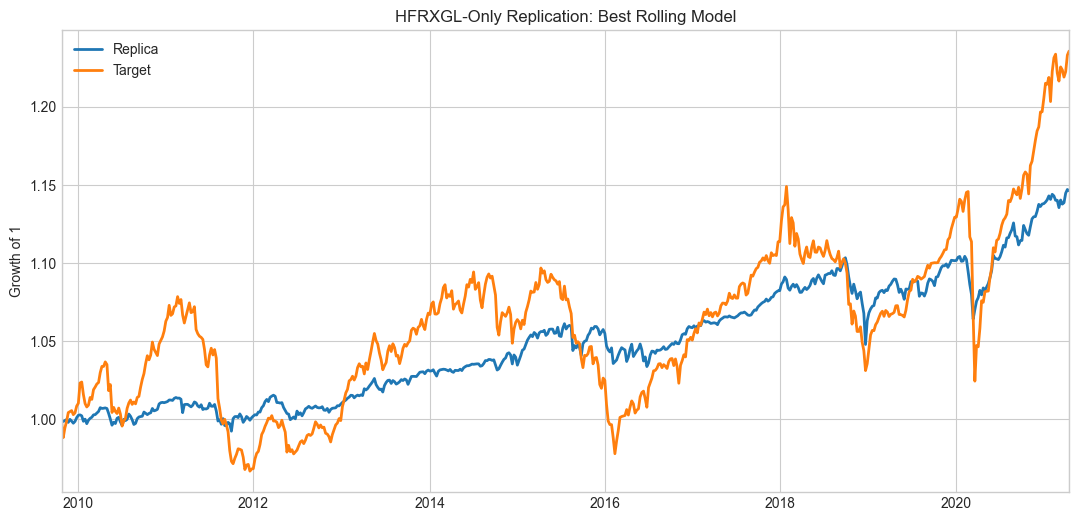

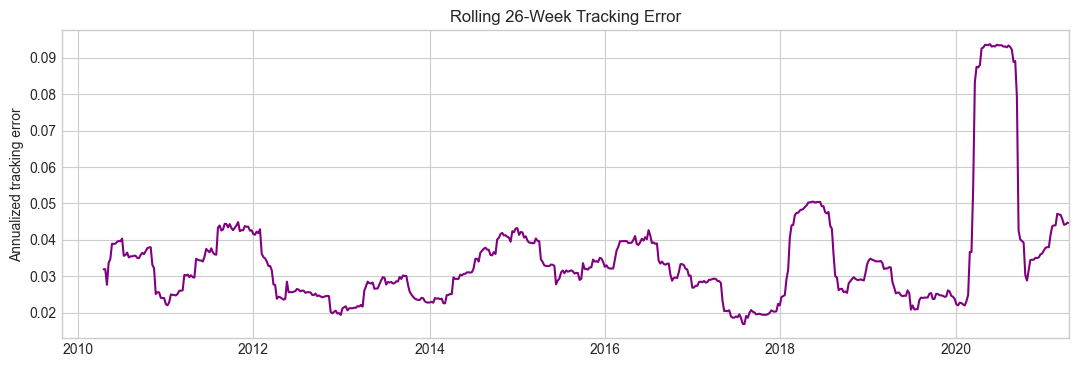

,Average Absolute Weight
TU2,0.1219
ES1,0.0463
TP1,0.0365
RX1,0.0185
NQ1,0.0094
CO1,0.0093
VG1,0.0077
DU1,0.0005
TY1,0.0000
GC1,0.0000


In [13]:
y_hfrx = returns_all["HFRXGL"].loc[X.index]

hfrx_grid = []
for window in [52, 104, 156]:
    for rebalance in [4, 12]:
        hfrx_grid.append({"model_type": "ols", "window": window, "rebalance_every": rebalance, "alpha": 0.0, "l1_ratio": 0.0, "top_k": None})
        for alpha in [0.1, 1.0, 10.0]:
            hfrx_grid.append({"model_type": "ridge", "window": window, "rebalance_every": rebalance, "alpha": alpha, "l1_ratio": 0.0, "top_k": None})
        for alpha in [0.001, 0.01]:
            hfrx_grid.append({"model_type": "lasso", "window": window, "rebalance_every": rebalance, "alpha": alpha, "l1_ratio": 1.0, "top_k": None})
        for alpha in [0.001, 0.01]:
            for l1_ratio in [0.3, 0.7]:
                hfrx_grid.append({"model_type": "elastic_net", "window": window, "rebalance_every": rebalance, "alpha": alpha, "l1_ratio": l1_ratio, "top_k": None})
        hfrx_grid.append({"model_type": "ridge", "window": window, "rebalance_every": rebalance, "alpha": 1.0, "l1_ratio": 0.0, "top_k": 5})
        hfrx_grid.append({"model_type": "elastic_net", "window": window, "rebalance_every": rebalance, "alpha": 0.001, "l1_ratio": 0.5, "top_k": 5})

hfrx_results = []
hfrx_details = {}

for spec in hfrx_grid:
    result, details = backtest_rolling_linear_custom(y_hfrx, X, **spec)
    result["Target Name"] = "HFRXGL"
    hfrx_results.append(result)
    hfrx_details[result["Model"]] = details

hfrx_results_df = pd.DataFrame(hfrx_results)
hfrx_leaderboard = hfrx_results_df.sort_values(["Tracking Error", "Correlation"], ascending=[True, False])
display(hfrx_leaderboard.head(12))

best_hfrx_label = hfrx_leaderboard.iloc[0]["Model"]
best_hfrx = hfrx_details[best_hfrx_label]

print("Best HFRXGL-only rolling model:")
print(best_hfrx_label)
display(hfrx_leaderboard.head(1).T)

plot_replication(best_hfrx["replica"], best_hfrx["target"], "HFRXGL-Only Replication: Best Rolling Model")

hfrx_weights_summary = best_hfrx["weights"].abs().mean().sort_values(ascending=False)
display(hfrx_weights_summary.to_frame("Average Absolute Weight"))

### 12.3 Market-Regime Analysis

Average full-sample performance can hide model weaknesses. This section compares the best rolling linear and Kalman models across crisis and non-crisis periods.

,Model,Regime,Obs,Replica Return,Target Return,Replica Vol,Target Vol,Tracking Error,Correlation,MAE,Replica Max Drawdown,Target Max Drawdown
0,Best Rolling Linear,Post-crisis / Euro crisis,114,0.0233,0.0163,0.0522,0.0599,0.0255,0.9057,0.0027,-0.0546,-0.1016
1,Best Rolling Linear,QE and low-vol expansion,366,0.0354,0.0344,0.0370,0.0439,0.0220,0.8650,0.0023,-0.0670,-0.1053
2,Best Rolling Linear,Covid shock and recovery,68,0.0837,0.0954,0.0721,0.0920,0.0521,0.8251,0.0042,-0.0876,-0.1339
3,Best Kalman Filter,Post-crisis / Euro crisis,114,0.0270,0.0163,0.0585,0.0599,0.0264,0.9010,0.0028,-0.0643,-0.1016
4,Best Kalman Filter,QE and low-vol expansion,366,0.0335,0.0344,0.0399,0.0439,0.0214,0.8738,0.0023,-0.0649,-0.1053
5,Best Kalman Filter,Covid shock and recovery,68,0.0691,0.0954,0.0718,0.0920,0.0503,0.8391,0.0042,-0.0938,-0.1339
6,Best HFRXGL Clone,Post-crisis / Euro crisis,166,0.0028,0.0009,0.0152,0.0367,0.0332,0.4256,0.0034,-0.0212,-0.1034
7,Best HFRXGL Clone,QE and low-vol expansion,366,0.0127,0.0179,0.0200,0.0370,0.0320,0.5019,0.0034,-0.0502,-0.1082
8,Best HFRXGL Clone,Covid shock and recovery,68,0.0308,0.0715,0.0278,0.0733,0.0654,0.4605,0.0058,-0.0363,-0.1058


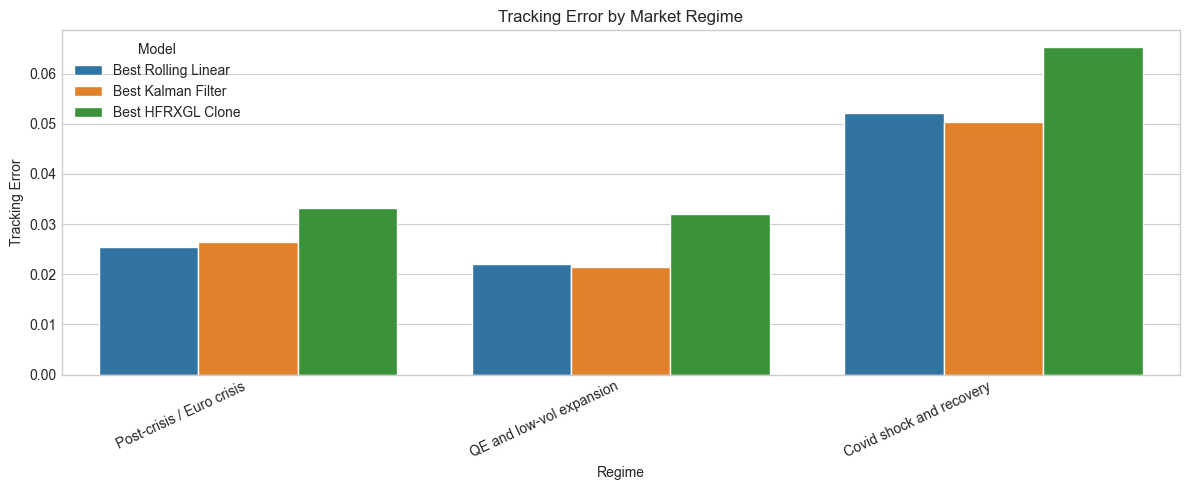

In [14]:
REGIMES = {
    "Global Financial Crisis": ("2007-10-23", "2009-03-31"),
    "Post-crisis / Euro crisis": ("2009-04-01", "2012-12-31"),
    "QE and low-vol expansion": ("2013-01-01", "2019-12-31"),
    "Covid shock and recovery": ("2020-01-01", "2021-04-20"),
}

def regime_metrics(replica, target, model_name):
    rows = []
    aligned = pd.concat([replica.rename("Replica"), target.rename("Target")], axis=1).dropna()

    for regime, (start, end) in REGIMES.items():
        subset = aligned.loc[start:end]
        if len(subset) < 8:
            continue
        rows.append({
            "Model": model_name,
            "Regime": regime,
            "Obs": len(subset),
            "Replica Return": annualized_return(subset["Replica"]),
            "Target Return": annualized_return(subset["Target"]),
            "Replica Vol": annualized_volatility(subset["Replica"]),
            "Target Vol": annualized_volatility(subset["Target"]),
            "Tracking Error": tracking_error(subset["Replica"], subset["Target"]),
            "Correlation": subset["Replica"].corr(subset["Target"]),
            "MAE": (subset["Replica"] - subset["Target"]).abs().mean(),
            "Replica Max Drawdown": max_drawdown(subset["Replica"]),
            "Target Max Drawdown": max_drawdown(subset["Target"]),
        })

    return rows

regime_rows = []
regime_rows.extend(regime_metrics(best_linear["replica"], best_linear["target"], "Best Rolling Linear"))
regime_rows.extend(regime_metrics(best_kalman["replica"], best_kalman["target"], "Best Kalman Filter"))
regime_rows.extend(regime_metrics(best_hfrx["replica"], best_hfrx["target"], "Best HFRXGL Clone"))

regime_df = pd.DataFrame(regime_rows)
display(regime_df)

plt.figure(figsize=(12, 5))
sns.barplot(data=regime_df, x="Regime", y="Tracking Error", hue="Model")
plt.title("Tracking Error by Market Regime")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### 12.4 Residual Diagnostics

Residuals are the weekly tracking errors. A good clone should have small, stable residuals with limited autocorrelation. Persistent residual autocorrelation would mean the model is missing a systematic component.

,Model,Mean Residual,Residual Vol Ann.,Residual MAE,Residual Skew,Residual Kurtosis,Worst Weekly Underperformance,Worst Weekly Outperformance
0,Best Rolling Linear,0.0000,0.0281,0.0027,1.9577,20.0246,-0.0183,0.0387
1,Best Kalman Filter,-0.0000,0.0276,0.0026,1.8265,18.5421,-0.0189,0.0374
2,Best HFRXGL Clone,-0.0001,0.0375,0.0037,1.6235,11.1014,-0.0192,0.0450


,Best Rolling Linear,Best Kalman Filter,Best HFRXGL Clone
Lag 1,-0.0912,-0.1246,-0.0612
Lag 2,-0.0017,-0.0315,0.0083
Lag 3,0.1298,0.1310,0.0845
Lag 4,-0.0908,-0.1052,-0.0875
Lag 5,0.0263,0.0358,0.0149
Lag 6,0.0449,0.0358,0.0076
Lag 7,-0.0315,-0.0365,-0.0048
Lag 8,0.0398,0.0860,0.0846
Lag 9,0.0323,-0.0015,0.0826
Lag 10,-0.0264,-0.0062,-0.0117


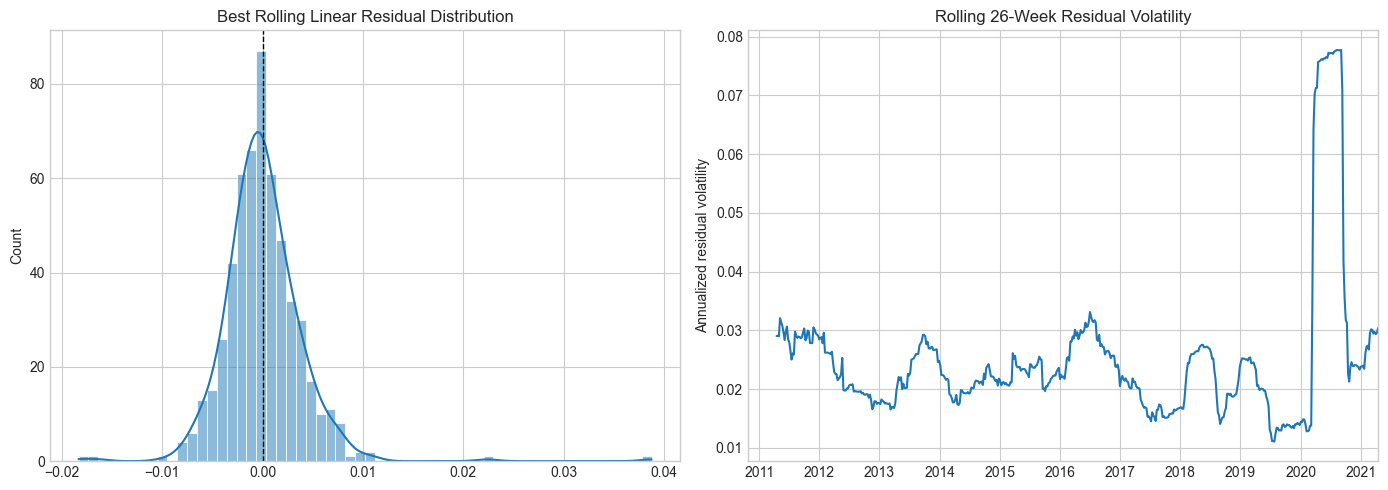

In [15]:
def residual_diagnostics(replica, target, label):
    aligned = pd.concat([replica.rename("Replica"), target.rename("Target")], axis=1).dropna()
    residual = aligned["Replica"] - aligned["Target"]

    stats_row = {
        "Model": label,
        "Mean Residual": residual.mean(),
        "Residual Vol Ann.": residual.std() * np.sqrt(ANNUAL_FACTOR),
        "Residual MAE": residual.abs().mean(),
        "Residual Skew": residual.skew(),
        "Residual Kurtosis": residual.kurtosis(),
        "Worst Weekly Underperformance": residual.min(),
        "Worst Weekly Outperformance": residual.max(),
    }

    acf = pd.Series({f"Lag {lag}": residual.autocorr(lag=lag) for lag in range(1, 13)})
    return residual, stats_row, acf

residual_rows = []
residual_acfs = {}
residual_series = {}

for label, details in [
    ("Best Rolling Linear", best_linear),
    ("Best Kalman Filter", best_kalman),
    ("Best HFRXGL Clone", best_hfrx),
]:
    residual, row, acf = residual_diagnostics(details["replica"], details["target"], label)
    residual_series[label] = residual
    residual_rows.append(row)
    residual_acfs[label] = acf

residual_stats_df = pd.DataFrame(residual_rows)
display(residual_stats_df)
display(pd.DataFrame(residual_acfs))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residual_series["Best Rolling Linear"], kde=True, ax=axes[0])
axes[0].set_title("Best Rolling Linear Residual Distribution")
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)

residual_series["Best Rolling Linear"].rolling(26).std().mul(np.sqrt(ANNUAL_FACTOR)).plot(ax=axes[1])
axes[1].set_title("Rolling 26-Week Residual Volatility")
axes[1].set_ylabel("Annualized residual volatility")
plt.tight_layout()
plt.show()

### 12.5 Gross Versus Net Performance After Transaction Costs

Transaction costs are small per trade, but they matter when a strategy rebalances often. This section compares gross returns before costs with net returns after 5 bps costs.

In [16]:
def gross_net_comparison(details, label):
    net = details["replica"]
    costs = details["costs"].reindex(net.index).fillna(0.0)
    gross = net + costs
    target = details["target"]

    gross_row = metrics_table(gross, target, label=f"{label} - Gross")
    net_row = metrics_table(net, target, label=f"{label} - Net")
    return gross_row, net_row

gross_net_rows = []
for label, details in [
    ("Best Rolling Linear", best_linear),
    ("Best Kalman Filter", best_kalman),
    ("Best HFRXGL Clone", best_hfrx),
]:
    gross_row, net_row = gross_net_comparison(details, label)
    gross_net_rows.extend([gross_row, net_row])

gross_net_df = pd.DataFrame(gross_net_rows)
display(gross_net_df[[
    "Model", "Replica Return", "Replica Vol", "Tracking Error",
    "Information Ratio", "Correlation", "Max Drawdown"
]])

,Model,Replica Return,Replica Vol,Tracking Error,Information Ratio,Correlation,Max Drawdown
0,Best Rolling Linear - Gross,0.0394,0.0461,0.0281,0.0440,0.8627,-0.0876
1,Best Rolling Linear - Net,0.0389,0.0460,0.0281,0.0247,0.8623,-0.0876
2,Best Kalman Filter - Gross,0.0369,0.0490,0.0276,-0.0456,0.8675,-0.0938
3,Best Kalman Filter - Net,0.0366,0.0490,0.0276,-0.0579,0.8675,-0.0938
4,Best HFRXGL Clone - Gross,0.0123,0.0198,0.0375,-0.1846,0.4724,-0.0502
5,Best HFRXGL Clone - Net,0.0120,0.0199,0.0375,-0.1922,0.4722,-0.0502


### 12.6 Turnover Thresholding

A practical trading rule is to ignore tiny suggested changes in weights. This reduces unnecessary trading and may improve net performance if the tracking loss is small.

,Threshold,Replica Return,Replica Vol,Tracking Error,Correlation,Average Turnover,Total Transaction Cost,Average Gross Exposure
4,0.1000,0.0386,0.0463,0.0280,0.8637,0.0165,0.0045,0.5736
3,0.0500,0.0386,0.0463,0.0281,0.8629,0.0187,0.0051,0.5739
2,0.0250,0.0388,0.0461,0.0281,0.8626,0.0203,0.0056,0.5741
0,0.0000,0.0389,0.0460,0.0281,0.8623,0.0209,0.0057,0.5738
1,0.0100,0.0389,0.0460,0.0281,0.8622,0.0209,0.0057,0.5738


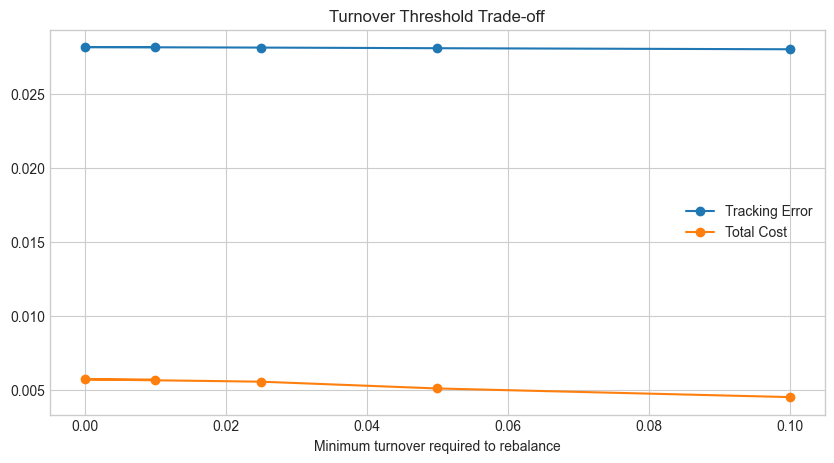

In [17]:
threshold_rows = []
threshold_details = {}

for threshold in [0.0, 0.01, 0.025, 0.05, 0.10]:
    result, details = backtest_rolling_linear_custom(
        y,
        X,
        model_type="elastic_net",
        window=156,
        rebalance_every=4,
        alpha=0.001,
        l1_ratio=0.3,
        top_k=None,
        turnover_threshold=threshold,
        charge_costs=True,
    )
    result["Threshold"] = threshold
    threshold_rows.append(result)
    threshold_details[threshold] = details

threshold_df = pd.DataFrame(threshold_rows).sort_values("Tracking Error")
display(threshold_df[[
    "Threshold", "Replica Return", "Replica Vol", "Tracking Error",
    "Correlation", "Average Turnover", "Total Transaction Cost",
    "Average Gross Exposure"
]])

plt.figure(figsize=(10, 5))
plt.plot(threshold_df["Threshold"], threshold_df["Tracking Error"], marker="o", label="Tracking Error")
plt.plot(threshold_df["Threshold"], threshold_df["Total Transaction Cost"], marker="o", label="Total Cost")
plt.title("Turnover Threshold Trade-off")
plt.xlabel("Minimum turnover required to rebalance")
plt.legend()
plt.show()

### 12.7 Constrained Long-Only Regression

Futures allow short positions, but a constrained benchmark is useful. This model solves a long-only least-squares problem with total exposure capped at 100%. It is less flexible, so it usually tracks worse, but it is easier to explain from a portfolio-control perspective.

In [18]:
from scipy.optimize import minimize

def fit_long_only_constrained_weights(X_train, y_train, max_gross=1.0, max_single=0.75, l2_penalty=1e-4):
    X_mat = X_train.values
    y_vec = y_train.values
    n_assets = X_mat.shape[1]

    def objective(w):
        residual = y_vec - X_mat @ w
        return float(np.mean(residual ** 2) + l2_penalty * np.sum(w ** 2))

    constraints = [{"type": "ineq", "fun": lambda w: max_gross - np.sum(w)}]
    bounds = [(0.0, max_single) for _ in range(n_assets)]
    x0 = np.repeat(min(max_gross / n_assets, max_single), n_assets)

    result = minimize(objective, x0, method="SLSQP", bounds=bounds, constraints=constraints)
    if not result.success:
        weights = x0
    else:
        weights = result.x

    return pd.Series(weights, index=X_train.columns)

def backtest_long_only_constrained(target_series, futures_X, window=156, rebalance_every=4, turnover_threshold=0.0):
    target_series = target_series.loc[futures_X.index].dropna()
    futures_X = futures_X.loc[target_series.index]

    dates = []
    replica_returns = []
    target_out = []
    weights_out = []
    turnover_out = []
    costs_out = []
    current_weights = pd.Series(0.0, index=futures_X.columns)

    for t in range(window, len(futures_X)):
        should_rebalance = ((t - window) % rebalance_every == 0)

        if should_rebalance:
            new_weights = fit_long_only_constrained_weights(
                futures_X.iloc[t - window:t],
                target_series.iloc[t - window:t],
            )
            proposed_turnover = float((new_weights - current_weights).abs().sum())
            if proposed_turnover >= turnover_threshold:
                current_weights = new_weights
                turnover = proposed_turnover
            else:
                turnover = 0.0
            cost = TRANSACTION_COST * turnover
        else:
            turnover = 0.0
            cost = 0.0

        dates.append(futures_X.index[t])
        replica_returns.append(float(futures_X.iloc[t].dot(current_weights) - cost))
        target_out.append(float(target_series.iloc[t]))
        weights_out.append(current_weights.copy())
        turnover_out.append(turnover)
        costs_out.append(cost)

    replica = pd.Series(replica_returns, index=dates, name="Replica")
    target = pd.Series(target_out, index=dates, name="Target")
    weights_df = pd.DataFrame(weights_out, index=dates)
    turnover_series = pd.Series(turnover_out, index=dates)
    cost_series = pd.Series(costs_out, index=dates)

    result = metrics_table(
        replica, target,
        weights=weights_df, turnover=turnover_series,
        costs=cost_series, label="Long-only constrained regression"
    )
    details = {
        "replica": replica,
        "target": target,
        "weights": weights_df,
        "turnover": turnover_series,
        "costs": cost_series,
    }
    return result, details

constrained_result, constrained_details = backtest_long_only_constrained(y, X, window=156, rebalance_every=4)
constrained_hfrx_result, constrained_hfrx_details = backtest_long_only_constrained(y_hfrx, X, window=156, rebalance_every=4)

constrained_compare = pd.DataFrame([
    metrics_table(best_linear["replica"], best_linear["target"], weights=best_linear["weights"], turnover=best_linear["turnover"], costs=best_linear["costs"], label="Best Rolling Elastic Net"),
    constrained_result,
    metrics_table(best_hfrx["replica"], best_hfrx["target"], weights=best_hfrx["weights"], turnover=best_hfrx["turnover"], costs=best_hfrx["costs"], label="Best HFRXGL Rolling Model"),
    constrained_hfrx_result | {"Model": "HFRXGL long-only constrained regression"},
])

display(constrained_compare[[
    "Model", "Replica Return", "Replica Vol", "Tracking Error",
    "Correlation", "Average Gross Exposure", "Average Turnover",
    "Total Transaction Cost"
]])

display(constrained_details["weights"].abs().mean().sort_values(ascending=False).to_frame("Constructed Target Long-Only Avg Weight"))

,Model,Replica Return,Replica Vol,Tracking Error,Correlation,Average Gross Exposure,Average Turnover,Total Transaction Cost
0,Best Rolling Elastic Net,0.0389,0.0460,0.0281,0.8623,0.5738,0.0209,0.0057
1,Long-only constrained regression,0.0454,0.0737,0.0484,0.7540,0.9565,0.0023,0.0006
2,Best HFRXGL Rolling Model,0.0120,0.0199,0.0375,0.4722,0.2501,0.0111,0.0033
3,HFRXGL long-only constrained regression,0.0322,0.0662,0.0612,0.4351,0.8749,0.0030,0.0008


,Constructed Target Long-Only Avg Weight
TY1,0.0913
RX1,0.0913
DU1,0.0908
TU2,0.0907
GC1,0.0876
ES1,0.0864
TP1,0.0862
NQ1,0.0859
VG1,0.0857
LLL1,0.0845


### 12.8 Kalman Filter Sensitivity

Process noise controls how quickly hidden weights can move. Observation noise controls how aggressively the filter trusts each new target return. The best setting here uses low process noise and high observation noise, meaning slowly changing weights and less reaction to weekly noise.

,Initial Window,Process Noise,Observation Noise Scale,Replica Return,Tracking Error,Correlation,Average Gross Exposure,Average Turnover
26,156,0.0025,2.0000,0.0366,0.0276,0.8675,1.0757,0.0130
14,104,0.0025,2.0000,0.0373,0.0276,0.8704,1.0419,0.0121
17,104,0.0050,2.0000,0.0376,0.0279,0.8681,1.0426,0.0126
29,156,0.0050,2.0000,0.0370,0.0279,0.8643,1.0741,0.0137
25,156,0.0025,1.0000,0.0361,0.0280,0.8630,1.1188,0.0202
13,104,0.0025,1.0000,0.0367,0.0281,0.8661,1.0637,0.0191
20,104,0.0100,2.0000,0.0385,0.0283,0.8635,1.0487,0.0145
32,156,0.0100,2.0000,0.0382,0.0285,0.8585,1.0745,0.0157
16,104,0.0050,1.0000,0.0377,0.0285,0.8614,1.0676,0.0207
28,156,0.0050,1.0000,0.0374,0.0286,0.8571,1.1139,0.0220


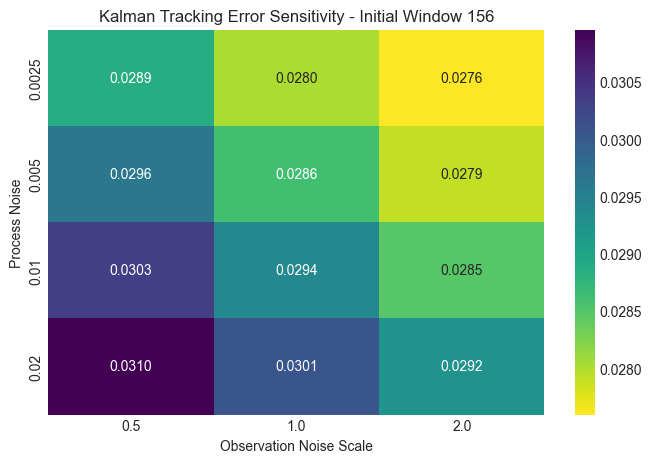

In [19]:
kalman_sensitivity = kalman_results_df.copy()
display(kalman_sensitivity.sort_values("Tracking Error").head(12)[[
    "Initial Window", "Process Noise", "Observation Noise Scale",
    "Replica Return", "Tracking Error", "Correlation",
    "Average Gross Exposure", "Average Turnover"
]])

best_window = int(kalman_leaderboard.iloc[0]["Initial Window"])
pivot_te = kalman_sensitivity[kalman_sensitivity["Initial Window"] == best_window].pivot_table(
    index="Process Noise",
    columns="Observation Noise Scale",
    values="Tracking Error",
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_te, annot=True, fmt=".4f", cmap="viridis_r")
plt.title(f"Kalman Tracking Error Sensitivity - Initial Window {best_window}")
plt.show()

## 13. Final Project Conclusion

The extended evidence supports three conclusions:

1. Linear models are appropriate for portfolio replication because regression coefficients can be interpreted as portfolio weights.
2. Penalized rolling regressions, especially Elastic Net, provide the strongest practical trade-off between tracking quality, exposure control, sparsity, and transaction costs.
3. The Kalman filter gives the best dynamic tracking in this dataset, but it is more complex and should be presented as the advanced model rather than the only final answer.

For a clean final recommendation, the rolling Elastic Net is the main implementable strategy and the Kalman filter is the advanced benchmark. The HFRXGL-only experiment strengthens the project because it connects directly to the hedge-fund replication motivation in the business case.

## 14. Replicating Other Available Targets

The dataset does not contain many named hedge funds, but it does contain other non-futures return series that can be treated as black-box targets:

- `MXWO`: MSCI World
- `MXWD`: MSCI World All Country
- `LEGATRUU`: Global Aggregate Bond
- `HFRXGL`: Hedge Fund Index
- the constructed target portfolio used earlier in the notebook

This section runs the same futures-replication framework on all of them. The goal is to see which targets are easy to replicate with the futures universe and which are structurally harder.

### 14.1 Custom Kalman Filter for Any Target

The earlier Kalman function was written for the constructed target. This version accepts any target return series, so it can be applied consistently to the other available targets.

In [20]:
def backtest_kalman_custom(
    target_series,
    futures_X,
    initial_window=104,
    process_noise=0.005,
    obs_noise_scale=1.0,
    turnover_threshold=0.0,
):
    target_series = target_series.loc[futures_X.index].dropna()
    futures_X = futures_X.loc[target_series.index]

    X_values = futures_X.values
    y_values = target_series.values
    dates = futures_X.index
    n_assets = futures_X.shape[1]

    initial_weights = initialize_ridge_weights(
        futures_X.iloc[:initial_window],
        target_series.iloc[:initial_window],
        alpha=1.0,
    )
    w = initial_weights.values.reshape(-1, 1)
    P = np.eye(n_assets) * 0.25

    Q = np.eye(n_assets) * (process_noise ** 2)
    base_obs_std = target_series.iloc[:initial_window].std()
    R = float((obs_noise_scale * base_obs_std) ** 2)
    R = max(R, 1e-10)

    replica_returns = []
    target_out = []
    weights_out = []
    turnover_out = []
    costs_out = []
    out_dates = []

    previous_weights = pd.Series(0.0, index=futures_X.columns)

    for t in range(initial_window, len(futures_X)):
        x_t = X_values[t].reshape(1, -1)

        w_pred = w
        P_pred = P + Q

        raw_trade_weights = pd.Series(w_pred.flatten(), index=futures_X.columns)
        hist_X = futures_X.iloc[max(0, t - initial_window):t]
        trade_weights, scale, gross, var_est = scale_weights_for_risk(raw_trade_weights, hist_X)

        proposed_turnover = float((trade_weights - previous_weights).abs().sum())
        if proposed_turnover >= turnover_threshold:
            effective_weights = trade_weights
            turnover = proposed_turnover
            previous_weights = effective_weights
        else:
            effective_weights = previous_weights
            turnover = 0.0

        cost = TRANSACTION_COST * turnover
        replica_return = float(futures_X.iloc[t].dot(effective_weights) - cost)

        y_pred = float(x_t @ w_pred)
        innovation = float(y_values[t] - y_pred)
        S = float(x_t @ P_pred @ x_t.T + R)
        K = (P_pred @ x_t.T) / S
        w = w_pred + K * innovation
        P = (np.eye(n_assets) - K @ x_t) @ P_pred

        out_dates.append(dates[t])
        replica_returns.append(replica_return)
        target_out.append(float(y_values[t]))
        weights_out.append(effective_weights.copy())
        turnover_out.append(turnover)
        costs_out.append(cost)

    replica = pd.Series(replica_returns, index=out_dates, name="Replica")
    target = pd.Series(target_out, index=out_dates, name="Target")
    weights_df = pd.DataFrame(weights_out, index=out_dates)
    turnover_series = pd.Series(turnover_out, index=out_dates, name="Turnover")
    cost_series = pd.Series(costs_out, index=out_dates, name="Transaction_Cost")

    label = f"kalman_custom_init{initial_window}_q{process_noise}_rscale{obs_noise_scale}"
    result = metrics_table(
        replica,
        target,
        weights=weights_df,
        turnover=turnover_series,
        costs=cost_series,
        label=label,
    )
    result.update({
        "Model Type": "kalman",
        "Initial Window": initial_window,
        "Process Noise": process_noise,
        "Observation Noise Scale": obs_noise_scale,
        "Turnover Threshold": turnover_threshold,
    })
    details = {
        "replica": replica,
        "target": target,
        "weights": weights_df,
        "turnover": turnover_series,
        "costs": cost_series,
    }
    return result, details

### 14.2 Multi-Target Linear and Kalman Runs

For each target, the notebook tries a compact but representative set of rolling linear models and Kalman filter settings. This keeps the experiment broad without making the project unnecessarily heavy.

In [21]:
additional_targets = {
    "Constructed Target": y,
    "HFRXGL": returns_all["HFRXGL"].loc[X.index],
    "MXWO": returns_all["MXWO"].loc[X.index],
    "MXWD": returns_all["MXWD"].loc[X.index],
    "LEGATRUU": returns_all["LEGATRUU"].loc[X.index],
}

compact_linear_grid = []
for window in [104, 156]:
    for rebalance in [4, 12]:
        compact_linear_grid.extend([
            {"model_type": "ols", "window": window, "rebalance_every": rebalance, "alpha": 0.0, "l1_ratio": 0.0, "top_k": None},
            {"model_type": "ridge", "window": window, "rebalance_every": rebalance, "alpha": 1.0, "l1_ratio": 0.0, "top_k": None},
            {"model_type": "ridge", "window": window, "rebalance_every": rebalance, "alpha": 10.0, "l1_ratio": 0.0, "top_k": None},
            {"model_type": "lasso", "window": window, "rebalance_every": rebalance, "alpha": 0.001, "l1_ratio": 1.0, "top_k": None},
            {"model_type": "elastic_net", "window": window, "rebalance_every": rebalance, "alpha": 0.001, "l1_ratio": 0.3, "top_k": None},
            {"model_type": "elastic_net", "window": window, "rebalance_every": rebalance, "alpha": 0.001, "l1_ratio": 0.7, "top_k": None},
            {"model_type": "ridge", "window": window, "rebalance_every": rebalance, "alpha": 1.0, "l1_ratio": 0.0, "top_k": 5},
            {"model_type": "elastic_net", "window": window, "rebalance_every": rebalance, "alpha": 0.001, "l1_ratio": 0.5, "top_k": 5},
        ])

compact_kalman_grid = []
for initial_window in [104, 156]:
    for process_noise in [0.0025, 0.005, 0.01]:
        for obs_noise_scale in [1.0, 2.0]:
            compact_kalman_grid.append({
                "initial_window": initial_window,
                "process_noise": process_noise,
                "obs_noise_scale": obs_noise_scale,
            })

multi_target_rows = []
multi_target_details = {}

for target_name, target_series in additional_targets.items():
    for spec in compact_linear_grid:
        result, details = backtest_rolling_linear_custom(target_series, X, **spec)
        result["Target Name"] = target_name
        result["Family"] = "Rolling Linear"
        multi_target_rows.append(result)
        multi_target_details[(target_name, result["Model"])] = details

    for spec in compact_kalman_grid:
        result, details = backtest_kalman_custom(target_series, X, **spec)
        result["Target Name"] = target_name
        result["Family"] = "Kalman Filter"
        multi_target_rows.append(result)
        multi_target_details[(target_name, result["Model"])] = details

multi_target_results_df = pd.DataFrame(multi_target_rows)

best_by_target = (
    multi_target_results_df
    .sort_values(["Target Name", "Tracking Error", "Correlation"], ascending=[True, True, False])
    .groupby("Target Name", as_index=False)
    .head(1)
    .sort_values("Tracking Error")
)

display(best_by_target[[
    "Target Name", "Family", "Model", "Obs", "Replica Return", "Target Return",
    "Replica Vol", "Target Vol", "Tracking Error", "Correlation",
    "Average Gross Exposure", "Average Turnover", "Total Transaction Cost"
]])

,Target Name,Family,Model,Obs,Replica Return,Target Return,Replica Vol,Target Vol,Tracking Error,Correlation,Average Gross Exposure,Average Turnover,Total Transaction Cost
39,Constructed Target,Kalman Filter,kalman_custom_init156_q0.0025_rscale2.0,548,0.0366,0.0382,0.0490,0.0554,0.0276,0.8675,1.0757,0.0130,0.0036
130,MXWO,Kalman Filter,kalman_custom_init156_q0.01_rscale1.0,548,0.1060,0.0957,0.1459,0.1485,0.0308,0.9783,1.7918,0.0147,0.0040
196,LEGATRUU,Rolling Linear,elastic_net_w156_reb4_a0.001_l10.3_topNone_thr0.0,548,0.0114,0.0226,0.0310,0.0487,0.0352,0.6919,1.5354,0.0476,0.0131
174,MXWD,Kalman Filter,kalman_custom_init156_q0.01_rscale1.0,548,0.1048,0.0881,0.1445,0.1486,0.0369,0.9687,1.8677,0.0165,0.0045
77,HFRXGL,Kalman Filter,kalman_custom_init104_q0.0025_rscale2.0,600,0.0166,0.0192,0.0247,0.0426,0.0375,0.4824,1.2826,0.0195,0.0058


### 14.3 Which Targets Are Easier to Replicate?

Lower tracking error and higher correlation indicate easier replication. Equity indices should generally be easier because the futures universe contains several liquid equity futures. Bond replication may be harder or easier depending on whether the available rates futures capture the duration and currency behavior of the target.

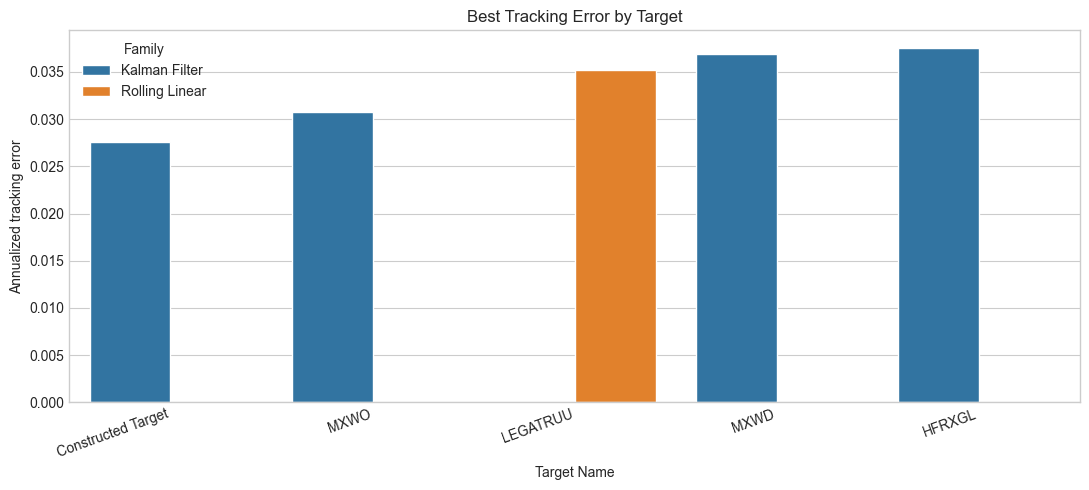

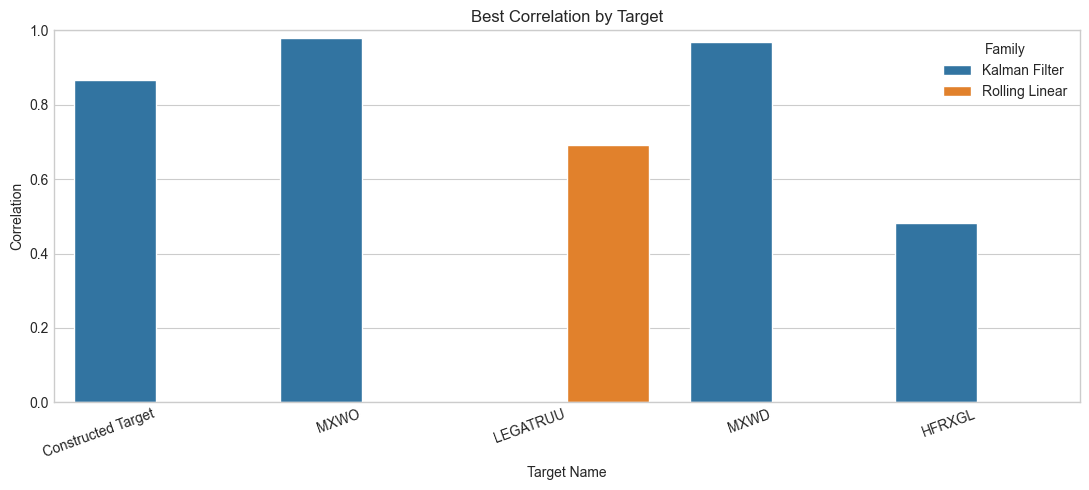

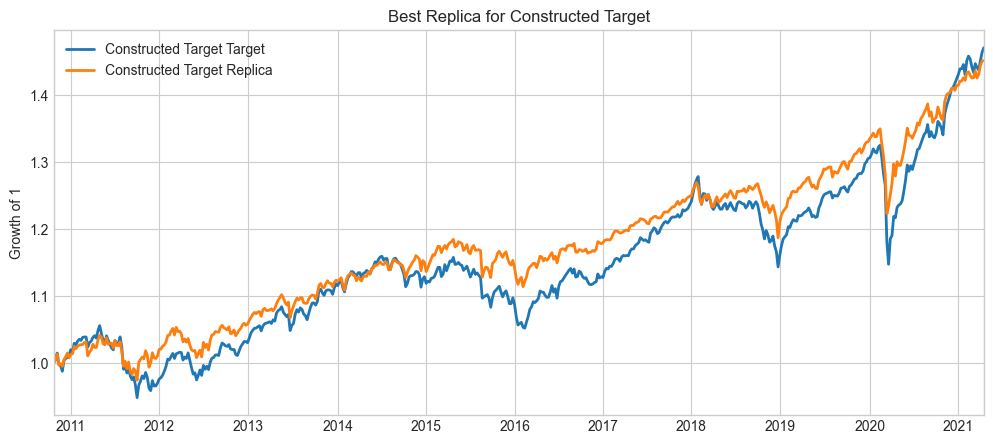

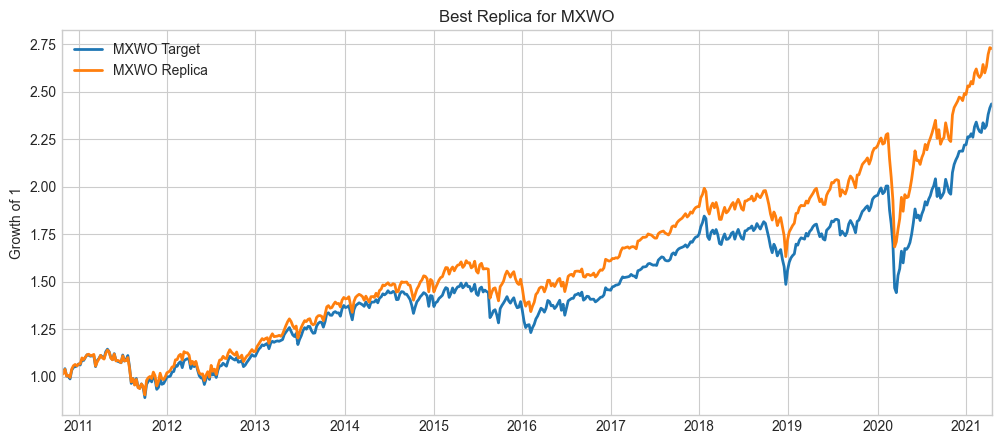

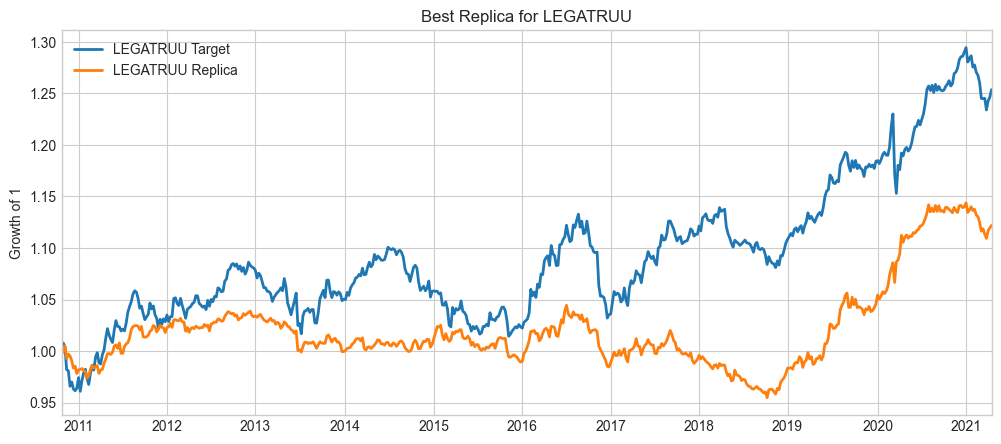

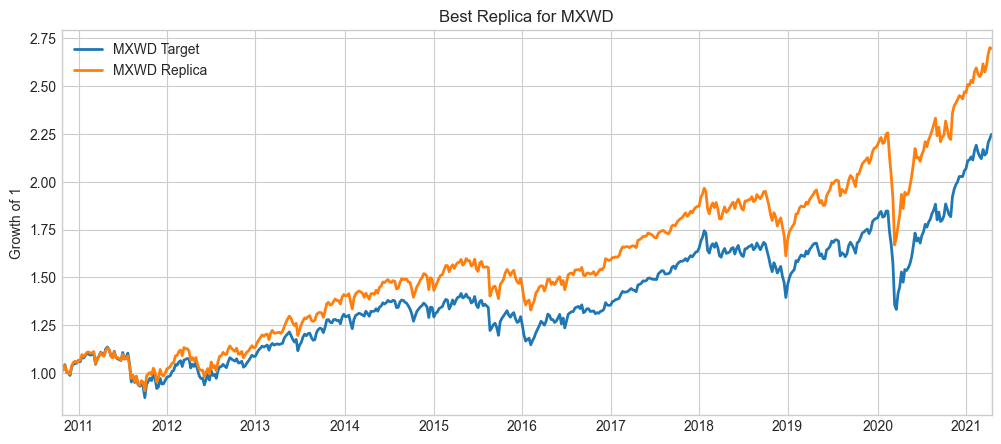

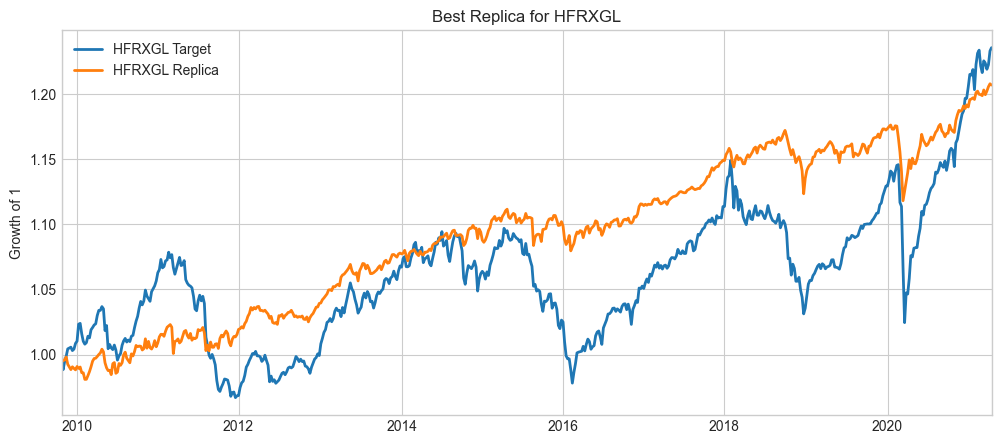

In [22]:
plt.figure(figsize=(11, 5))
sns.barplot(data=best_by_target, x="Target Name", y="Tracking Error", hue="Family")
plt.title("Best Tracking Error by Target")
plt.ylabel("Annualized tracking error")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
sns.barplot(data=best_by_target, x="Target Name", y="Correlation", hue="Family")
plt.title("Best Correlation by Target")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

selected_target_labels = best_by_target["Target Name"].tolist()
comparison_curves = {}

for target_name in selected_target_labels:
    row = best_by_target[best_by_target["Target Name"] == target_name].iloc[0]
    details = multi_target_details[(target_name, row["Model"])]
    aligned = pd.concat([
        details["target"].rename(f"{target_name} Target"),
        details["replica"].rename(f"{target_name} Replica"),
    ], axis=1).dropna()
    comparison_curves[target_name] = aligned

for target_name, aligned in comparison_curves.items():
    cumulative = (1 + aligned).cumprod()
    ax = cumulative.plot(figsize=(12, 5), linewidth=2)
    ax.set_title(f"Best Replica for {target_name}")
    ax.set_ylabel("Growth of 1")
    plt.show()

### 14.4 Factor Interpretation Across Targets

The average absolute weights show which futures are most important for each target. This is useful for interpretation: the project is not only forecasting returns, it is also identifying which liquid risk factors explain each black-box series.

,Target Name,Future,Average Absolute Weight,Model,Family
9,Constructed Target,DU1,0.4104,kalman_custom_init156_q0.0025_rscale2.0,Kalman Filter
4,Constructed Target,ES1,0.1885,kalman_custom_init156_q0.0025_rscale2.0,Kalman Filter
1,Constructed Target,TY1,0.1539,kalman_custom_init156_q0.0025_rscale2.0,Kalman Filter
5,Constructed Target,VG1,0.0745,kalman_custom_init156_q0.0025_rscale2.0,Kalman Filter
0,Constructed Target,RX1,0.0604,kalman_custom_init156_q0.0025_rscale2.0,Kalman Filter
53,HFRXGL,DU1,0.4775,kalman_custom_init104_q0.0025_rscale2.0,Kalman Filter
54,HFRXGL,TU2,0.4035,kalman_custom_init104_q0.0025_rscale2.0,Kalman Filter
44,HFRXGL,RX1,0.1449,kalman_custom_init104_q0.0025_rscale2.0,Kalman Filter
45,HFRXGL,TY1,0.0726,kalman_custom_init104_q0.0025_rscale2.0,Kalman Filter
52,HFRXGL,TP1,0.0533,kalman_custom_init104_q0.0025_rscale2.0,Kalman Filter


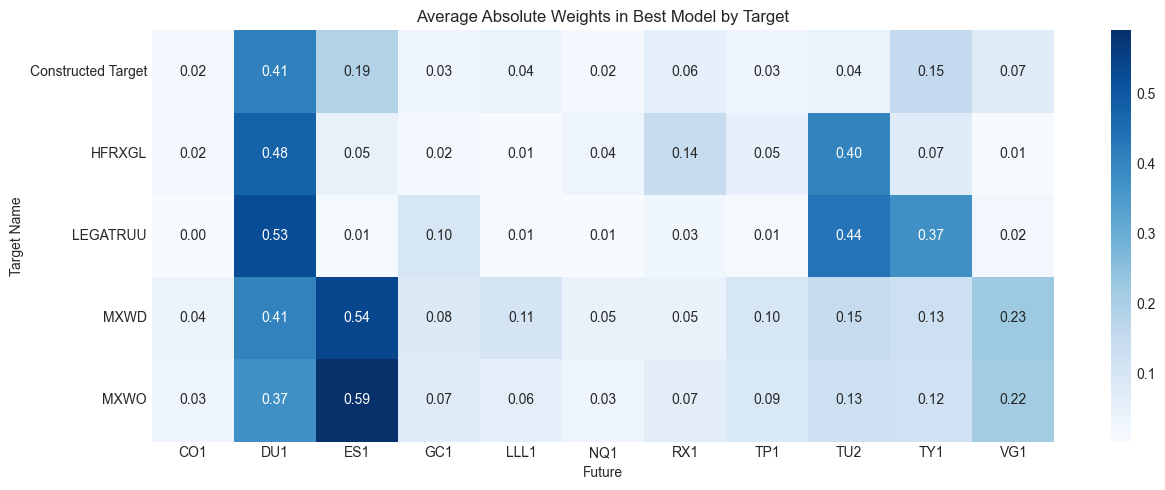

In [23]:
weight_summary_rows = []

for _, row in best_by_target.iterrows():
    target_name = row["Target Name"]
    model_name = row["Model"]
    details = multi_target_details[(target_name, model_name)]
    avg_abs = details["weights"].abs().mean()

    for future, value in avg_abs.items():
        weight_summary_rows.append({
            "Target Name": target_name,
            "Future": future,
            "Average Absolute Weight": value,
            "Model": model_name,
            "Family": row["Family"],
        })

multi_weight_summary = pd.DataFrame(weight_summary_rows)
display(
    multi_weight_summary
    .sort_values(["Target Name", "Average Absolute Weight"], ascending=[True, False])
    .groupby("Target Name")
    .head(5)
)

pivot_weights = multi_weight_summary.pivot_table(
    index="Target Name",
    columns="Future",
    values="Average Absolute Weight",
).fillna(0)

plt.figure(figsize=(13, 5))
sns.heatmap(pivot_weights, annot=True, fmt=".2f", cmap="Blues")
plt.title("Average Absolute Weights in Best Model by Target")
plt.tight_layout()
plt.show()

### 14.5 Comment on Other Targets

This additional experiment turns the project into a broader replication study. Instead of only asking whether one constructed target can be replicated, it tests which types of target returns are naturally spanned by the available futures contracts.

In general:

- Equity-like targets should be replicated mainly with `ES1`, `NQ1`, `VG1`, `TP1`, and `LLL1`.
- Bond-like targets should rely more on `RX1`, `TY1`, `DU1`, and `TU2`.
- Hedge-fund-like targets should require a mixed exposure and may benefit more from dynamic models because the exposures are less stable.

This is useful for the final presentation because it demonstrates that the method is general, not tailored only to one target.